# MAS Cross-Run Comparison Notebook
### Compare multiple runs side-by-side (e.g. 5 FPS vs 10 FPS vs 15 FPS)

**Purpose:** This notebook is designed exclusively for *cross-run comparison*. Each run is a folder
containing `metrics.json`, `cpu.csv`, `mem.csv`, `temp.csv`, and a parsed `report.md` (as a dict).
All analyses from the single-run notebook are reproduced here as **comparative, multi-series plots**.

**Sections:**
1. Configuration & data loading
2. Global run summary table
3. Frame capture comparison (total & suited distributions)
4. Prediction error comparison (MAE, MAPE, error distributions)
5. Tradeoff: suited frames → prediction error, per run
6. Selector quality comparison (F1, precision, recall)
7. Timing comparison (lead time, latency, processing delay)
8. Resource telemetry comparison (CPU, RAM, temperature)
9. Resource footprint per animal (CPU/temp during processing windows)
10. Outlier analysis per run
11. Summary comparison dashboard
12. Key insights & recommendations


## 0. Setup & Dependencies

In [3]:
import os, io, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from datetime import datetime
from scipy import stats
from scipy.stats import spearmanr

warnings.filterwarnings("ignore")

# ── Global aesthetics ────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titleweight":  "bold",
    "axes.titlesize":    12,
    "figure.facecolor":  "white",
})

# Colour palette — one distinct colour per run (up to 6 runs)
RUN_COLORS = ["#2B7BB9", "#E8593C", "#2CA02C", "#9467BD", "#8C564B", "#F7B731"]
OUTLIER_THRESH = 50.0   # % relative error — animals above this are flagged as anomalies

print("✓ Libraries loaded")


✓ Libraries loaded


## 1. Configuration — Define Your Runs

Edit the `RUNS` list below. Each entry is a dict with:
- `label`: short name shown in plots (e.g. `"15 FPS"`)
- `folder`: path to the run folder containing `metrics.json`, `cpu.csv`, `mem.csv`, `temp.csv`
- `report_csv`: path to the report CSV **or** an inline CSV string (see the helper below)
- `fps`: nominal FPS used in that run (for labelling)

The report CSV must have exactly these columns:
`animal_id, gt_weight, pred_weight, abs_error, rel_error_pct, total_frames, suited_pred, suited_gt, precision, recall, f1`

You can generate `report_csv` from your `report.md` using the `parse_report_md()` helper below.


In [4]:
# ══════════════════════════════════════════════════════════════════════════
#  >>>  EDIT THIS BLOCK  <<<
# ══════════════════════════════════════════════════════════════════════════

RUNS = [
    {
        "label":      "15 FPS",
        "fps":        15,
        "folder":     "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T15:54:32.792410",
        "report_csv": "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T15:54:32.792410/report.md",   # or use parse_report_md() below
    },
    {
        "label":      "10 FPS",
        "fps":        10,
        "folder":     "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T16:53:49.862882",
        "report_csv": "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T16:53:49.862882/report.md",
    },
    {
        "label":      "5 FPS",
        "fps":        5,
        "folder":     "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T17:31:46.666495/",
        "report_csv": "/Users/gabriellopesbastos/Projects/PIBIC/cv-system/infra/reports/mas-single_2026-06-18T17:31:46.666495/report.md",
    },
]

# ══════════════════════════════════════════════════════════════════════════
#  GOOGLE COLAB: uncomment and run to upload all run folders
# ══════════════════════════════════════════════════════════════════════════
# try:
#     from google.colab import files
#     import shutil
#     print("Upload all files for all runs (metrics.json, csv files):")
#     uploaded = files.upload()
#     # organise manually after uploading, or use a zip + unzip approach
# except ImportError:
#     pass

print(f"Configured {len(RUNS)} runs: {[r['label'] for r in RUNS]}")


Configured 3 runs: ['15 FPS', '10 FPS', '5 FPS']


## 2. Data Loading Helpers

In [5]:
# ── Helper: parse report.md into a DataFrame ───────────────────────────────
import re

def parse_report_md(md_path: str) -> pd.DataFrame:
    """
    Parse the Markdown report generated by the MAS evaluator into a tidy DataFrame.
    Extracts the summary table (animal_id, gt_weight, pred_weight, abs_error,
    rel_error_pct, total_frames, suited_pred, suited_gt, precision, recall, f1).
    """
    with open(md_path, encoding="utf-8") as f:
        content = f.read()

    # Find the summary table block (between first |---| separator and next ## heading)
    pattern = r'\| Animal.*?\n((?:\|.*\n)+)'
    match = re.search(pattern, content)
    if not match:
        raise ValueError(f"Could not find summary table in {md_path}")

    rows = []
    for line in match.group(1).splitlines():
        line = line.strip()
        if not line or line.startswith("|---") or line.startswith("| ---"):
            continue
        parts = [p.strip() for p in line.strip("|").split("|")]
        if len(parts) < 11:
            continue
        try:
            rows.append({
                "animal_id":      parts[0],
                "gt_weight":      float(parts[1]),
                "pred_weight":    float(parts[2]),
                "abs_error":      float(parts[3]),
                "rel_error_pct":  float(parts[4].strip('%')),
                "total_frames":   int(parts[5]),
                "suited_pred":    int(parts[6]),
                "suited_gt":      int(parts[7]),
                "precision":      float(parts[8]),
                "recall":         float(parts[9]),
                "f1":             float(parts[10]),
            })
        except (ValueError, IndexError):
            continue
    return pd.DataFrame(rows)


# ── Helper: load a single run ───────────────────────────────────────────────
def load_run(cfg: dict) -> dict:
    """
    Load all data for one run configuration.
    Returns a dict with keys: label, fps, df_animals, df_imgs,
    df_cpu, df_mem, df_temp, df_report, load_model_dur_ms
    """
    folder = cfg["folder"]
    label  = cfg["label"]
    fps    = cfg.get("fps", "?")

    # ── metrics.json ──────────────────────────────────────────────────────
    with open(os.path.join(folder, "metrics.json")) as f:
        raw = json.load(f)

    load_dur_ms = (
        datetime.fromisoformat(raw["load_model_final"]) -
        datetime.fromisoformat(raw["load_model_start"])
    ).total_seconds() * 1000

    rows_a, rows_i = [], []
    for aid, info in raw["animals"].items():
        fc  = datetime.fromisoformat(info["first_image_capture_time"])  if info.get("first_image_capture_time")  else None
        lc  = datetime.fromisoformat(info["last_image_capture_time"])   if info.get("last_image_capture_time")   else None
        pf  = datetime.fromisoformat(info["weight_prediction_final"])   if info.get("weight_prediction_final")   else None
        lt  = (pf - fc).total_seconds() if (pf and fc) else np.nan
        lat = (pf - lc).total_seconds() if (pf and lc) else np.nan
        delays = []
        for idx, img in info.get("imgs", {}).items():
            if "weight_prediction_start" in img and "weight_prediction_final" in img:
                t0 = datetime.fromisoformat(img["weight_prediction_start"])
                t1 = datetime.fromisoformat(img["weight_prediction_final"])
                d  = (t1 - t0).total_seconds()
                delays.append(d)
                rows_i.append({"animal_id": aid, "image_index": idx,
                                "prediction_duration_sec": d, "label": img.get("label")})
        rows_a.append({
            "animal_id": aid,
            "first_image_capture_time": fc,
            "last_image_capture_time":  lc,
            "weight_prediction_final":  pf,
            "total_of_images":          info.get("total_of_images", 0),
            "suitable_images":          info.get("suitable_images", 0),
            "by_animal_lead_time_sec":  lt,
            "by_animal_latency_sec":    lat,
            "by_animal_processing_delay_sec": sum(delays) if delays else 0.0,
        })

    df_animals = pd.DataFrame(rows_a)
    df_imgs    = pd.DataFrame(rows_i)

    # ── CSVs ──────────────────────────────────────────────────────────────
    def load_ts(name):
        df = pd.read_csv(os.path.join(folder, name))
        df["timestamp"] = pd.to_datetime(df["timestamp"])
        return df.sort_values("timestamp").reset_index(drop=True)

    df_cpu  = load_ts("cpu.csv")
    df_mem  = load_ts("mem.csv")
    df_temp = load_ts("temp.csv")

    cores = [c for c in df_cpu.columns if c.startswith("cpu_core_")]
    df_cpu["cpu_mean"] = df_cpu[cores].mean(axis=1)
    df_mem["ram_gb"]   = df_mem["used"] / 1e9

    # ── Report ────────────────────────────────────────────────────────────
    rpt = cfg["report_csv"]
    if isinstance(rpt, str) and os.path.isfile(rpt):
        if rpt.endswith(".md"):
            df_report = parse_report_md(rpt)
        else:
            df_report = pd.read_csv(rpt)
    elif isinstance(rpt, str):
        df_report = pd.read_csv(io.StringIO(rpt.strip()))
    else:
        df_report = rpt  # already a DataFrame

    df_report["is_outlier"] = df_report["rel_error_pct"] >= OUTLIER_THRESH
    df_report["suited_ratio"] = df_report["suited_pred"] / df_report["total_frames"].replace(0, np.nan)

    print(f"  ✓ [{label}]  animals={len(df_animals)}  "
          f"report={len(df_report)}  "
          f"outliers={df_report.is_outlier.sum()}  "
          f"load={load_dur_ms:.1f}ms")

    return {
        "label":           label,
        "fps":             fps,
        "df_animals":      df_animals,
        "df_imgs":         df_imgs,
        "df_cpu":          df_cpu,
        "df_mem":          df_mem,
        "df_temp":         df_temp,
        "df_report":       df_report,
        "load_model_ms":   load_dur_ms,
    }


# ── Load all runs ─────────────────────────────────────────────────────────────
print("Loading runs...")
LOADED = [load_run(cfg) for cfg in RUNS]
print(f"\n✓ Loaded {len(LOADED)} run(s): {[r['label'] for r in LOADED]}")


Loading runs...
  ✓ [15 FPS]  animals=189  report=189  outliers=6  load=43.2ms
  ✓ [10 FPS]  animals=189  report=189  outliers=6  load=43.1ms
  ✓ [5 FPS]  animals=189  report=189  outliers=6  load=42.6ms

✓ Loaded 3 run(s): ['15 FPS', '10 FPS', '5 FPS']


## 3. Global Run Summary Table

In [6]:
summary_rows = []

for run in LOADED:
    da   = run["df_animals"]
    dr   = run["df_report"]
    drc  = dr[~dr.is_outlier]
    dc   = run["df_cpu"]
    dm   = run["df_mem"]
    dt   = run["df_temp"]

    t0   = da["first_image_capture_time"].min()
    t1   = da["weight_prediction_final"].max()
    dur  = (t1 - t0).total_seconds()

    summary_rows.append({
        "Run":               run["label"],
        "FPS":               run["fps"],
        "Duration (min)":    round(dur / 60, 1),
        "Animals":           da["animal_id"].nunique(),
        "Total frames (Σ)":  int(da["total_of_images"].sum()),
        "Suited frames (Σ)": int(da["suitable_images"].sum()),
        "Suited ratio (%)":  round(da["suitable_images"].sum() / da["total_of_images"].sum() * 100, 1),
        "Avg frames/animal": round(da["total_of_images"].mean(), 1),
        "Avg suited/animal": round(da["suitable_images"].mean(), 1),
        "Throughput (a/hr)": round(da["animal_id"].nunique() / (dur / 3600), 1),
        "Overall FPS":       round(da["total_of_images"].sum() / dur, 2),
        "MAE (kg)":          round(drc["abs_error"].mean(), 3),
        "MAPE (%)":          round(drc["rel_error_pct"].mean(), 2),
        "Median err (%)":    round(drc["rel_error_pct"].median(), 2),
        "< 10% err (%)":     round((drc["rel_error_pct"] < 10).mean() * 100, 1),
        "Outliers":          int(dr["is_outlier"].sum()),
        "Avg F1":            round(drc["f1"].mean(), 4),
        "Avg CPU (%)":       round(dc["cpu_mean"].mean(), 2),
        "Avg RAM (%)":       round(dm["percent"].mean(), 2),
        "Avg Temp (°C)":     round(dt["temperature"].mean(), 2),
        "Peak Temp (°C)":    round(dt["temperature"].max(), 1),
        "Model load (ms)":   round(run["load_model_ms"], 1),
    })

df_summary = pd.DataFrame(summary_rows).set_index("Run")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)
display(df_summary.T)


Run,15 FPS,10 FPS,5 FPS
FPS,15.0000,10.0000,5.0000
Duration (min),24.9000,24.6000,25.0000
Animals,189.0000,189.0000,189.0000
Total frames (Σ),21643.0000,14468.0000,7291.0000
Suited frames (Σ),2646.0000,1770.0000,879.0000
Suited ratio (%),12.2000,12.2000,12.1000
Avg frames/animal,114.5000,76.6000,38.6000
Avg suited/animal,14.0000,9.4000,4.7000
Throughput (a/hr),455.1000,461.0000,453.3000
Overall FPS,14.4800,9.8000,4.8600


## 4. Frame Capture Comparison
Total frames and suited frames distributions side-by-side, plus suited conversion rates.


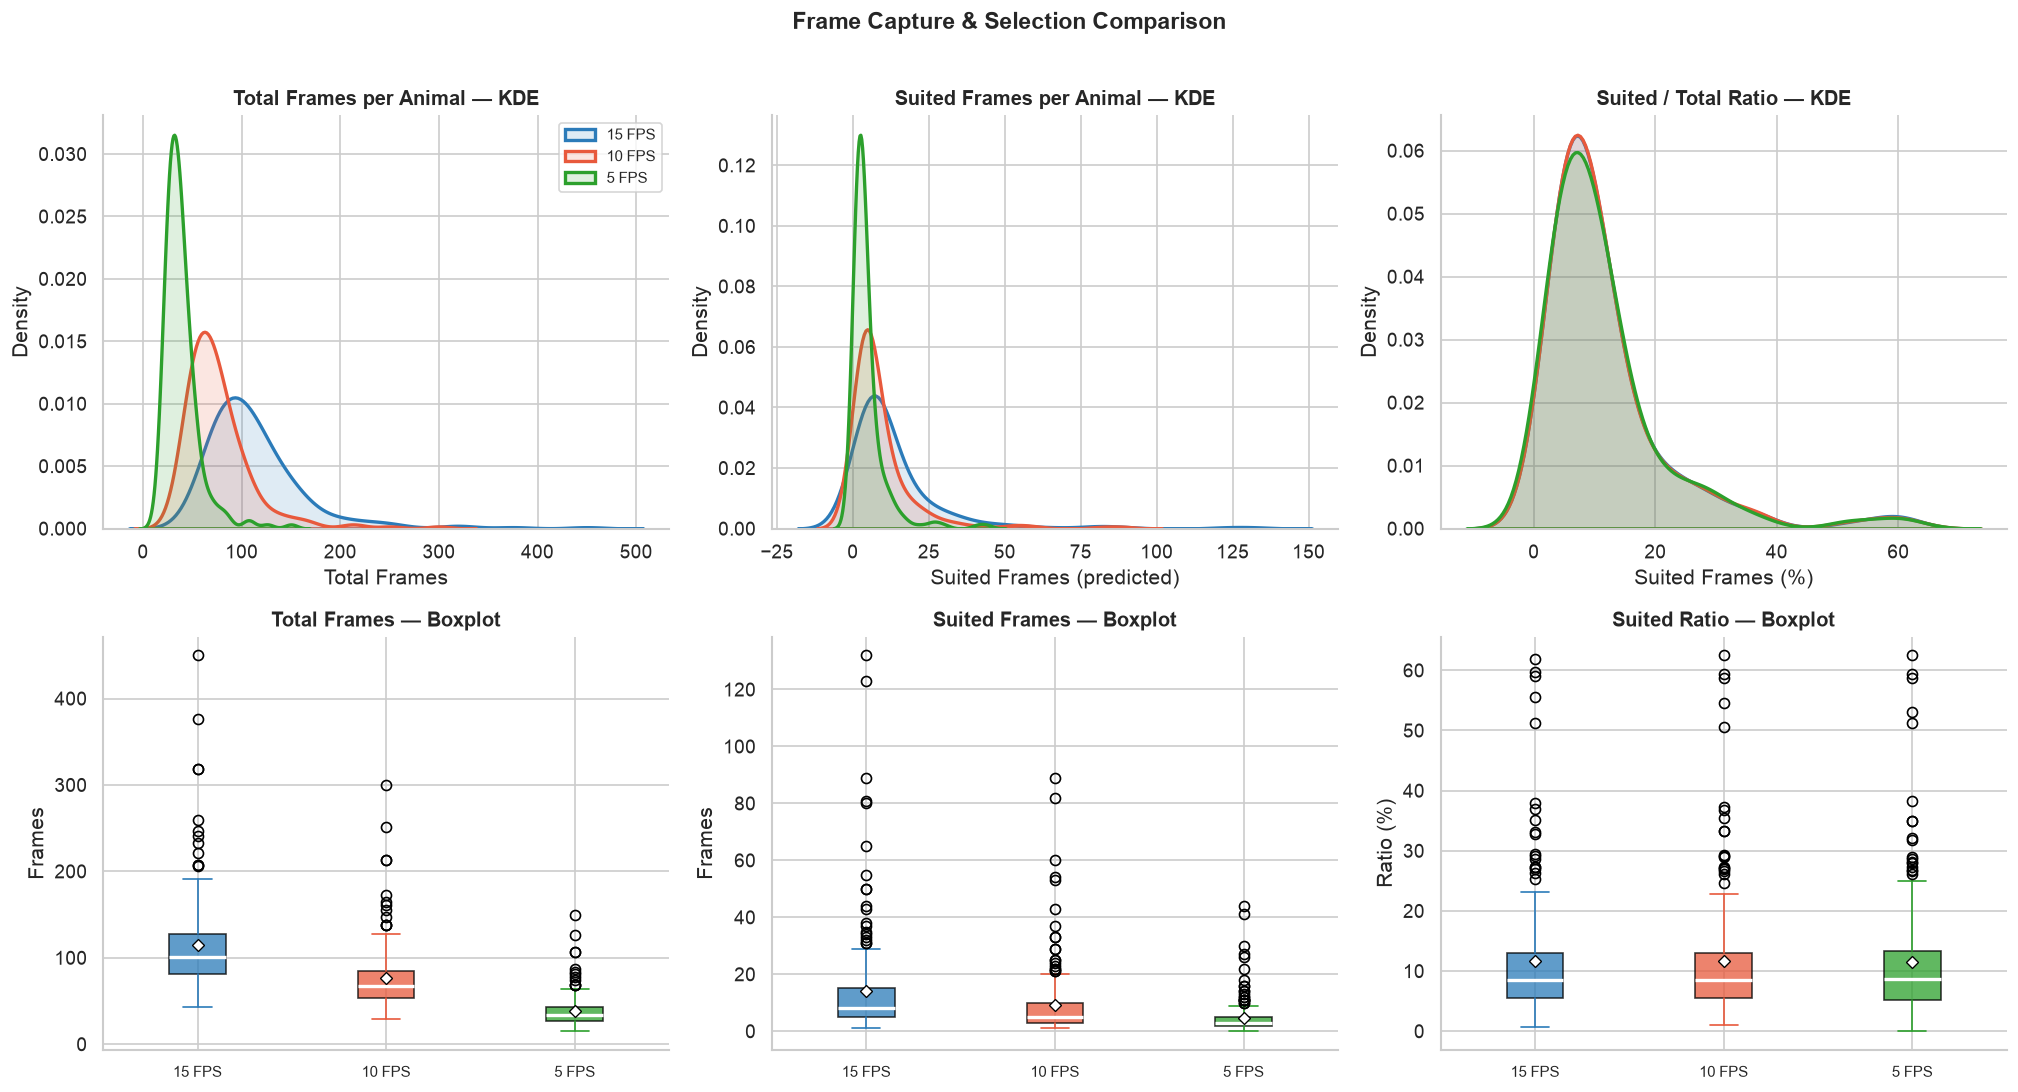

In [7]:
n = len(LOADED)
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

# ── Row 0: KDE overlays ─────────────────────────────────────────────────────
for run, color in zip(LOADED, RUN_COLORS):
    dr = run["df_report"]
    # Total frames
    sns.kdeplot(dr["total_frames"], ax=axes[0][0], color=color,
                lw=2, fill=True, alpha=0.15, label=run["label"])
    # Suited frames
    sns.kdeplot(dr["suited_pred"], ax=axes[0][1], color=color,
                lw=2, fill=True, alpha=0.15)
    # Suited ratio %
    ratio_pct = dr["suited_pred"] / dr["total_frames"] * 100
    sns.kdeplot(ratio_pct, ax=axes[0][2], color=color,
                lw=2, fill=True, alpha=0.15)

axes[0][0].set_title("Total Frames per Animal — KDE")
axes[0][0].set_xlabel("Total Frames")
axes[0][0].legend(fontsize=9)
axes[0][1].set_title("Suited Frames per Animal — KDE")
axes[0][1].set_xlabel("Suited Frames (predicted)")
axes[0][2].set_title("Suited / Total Ratio — KDE")
axes[0][2].set_xlabel("Suited Frames (%)")

# ── Row 1: Box plots ────────────────────────────────────────────────────────
def boxplot_metric(ax, metric_fn, ylabel, title):
    data = [metric_fn(r["df_report"]) for r in LOADED]
    labels = [r["label"] for r in LOADED]
    bp = ax.boxplot(data, patch_artist=True, notch=False,
                    medianprops=dict(color="white", lw=2))
    for patch, color in zip(bp["boxes"], RUN_COLORS[:n]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for whisker, color in zip(bp["whiskers"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        whisker.set_color(color)
    for cap, color in zip(bp["caps"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        cap.set_color(color)
    ax.set_xticks(range(1, n+1))
    ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    # Overlay mean markers
    for i, d in enumerate(data, 1):
        ax.plot(i, np.mean(d), "D", color="white", ms=5, zorder=5, markeredgecolor="black", markeredgewidth=0.8)

boxplot_metric(axes[1][0], lambda dr: dr["total_frames"],                    "Frames",   "Total Frames — Boxplot")
boxplot_metric(axes[1][1], lambda dr: dr["suited_pred"],                     "Frames",   "Suited Frames — Boxplot")
boxplot_metric(axes[1][2], lambda dr: dr["suited_pred"]/dr["total_frames"]*100, "Ratio (%)", "Suited Ratio — Boxplot")

plt.suptitle("Frame Capture & Selection Comparison", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cmp_frame_capture.png", dpi=120, bbox_inches="tight")
plt.show()


## 5. Prediction Error Comparison
MAE, MAPE and error distributions, excluding statistical anomalies (relative error ≥ 50%).


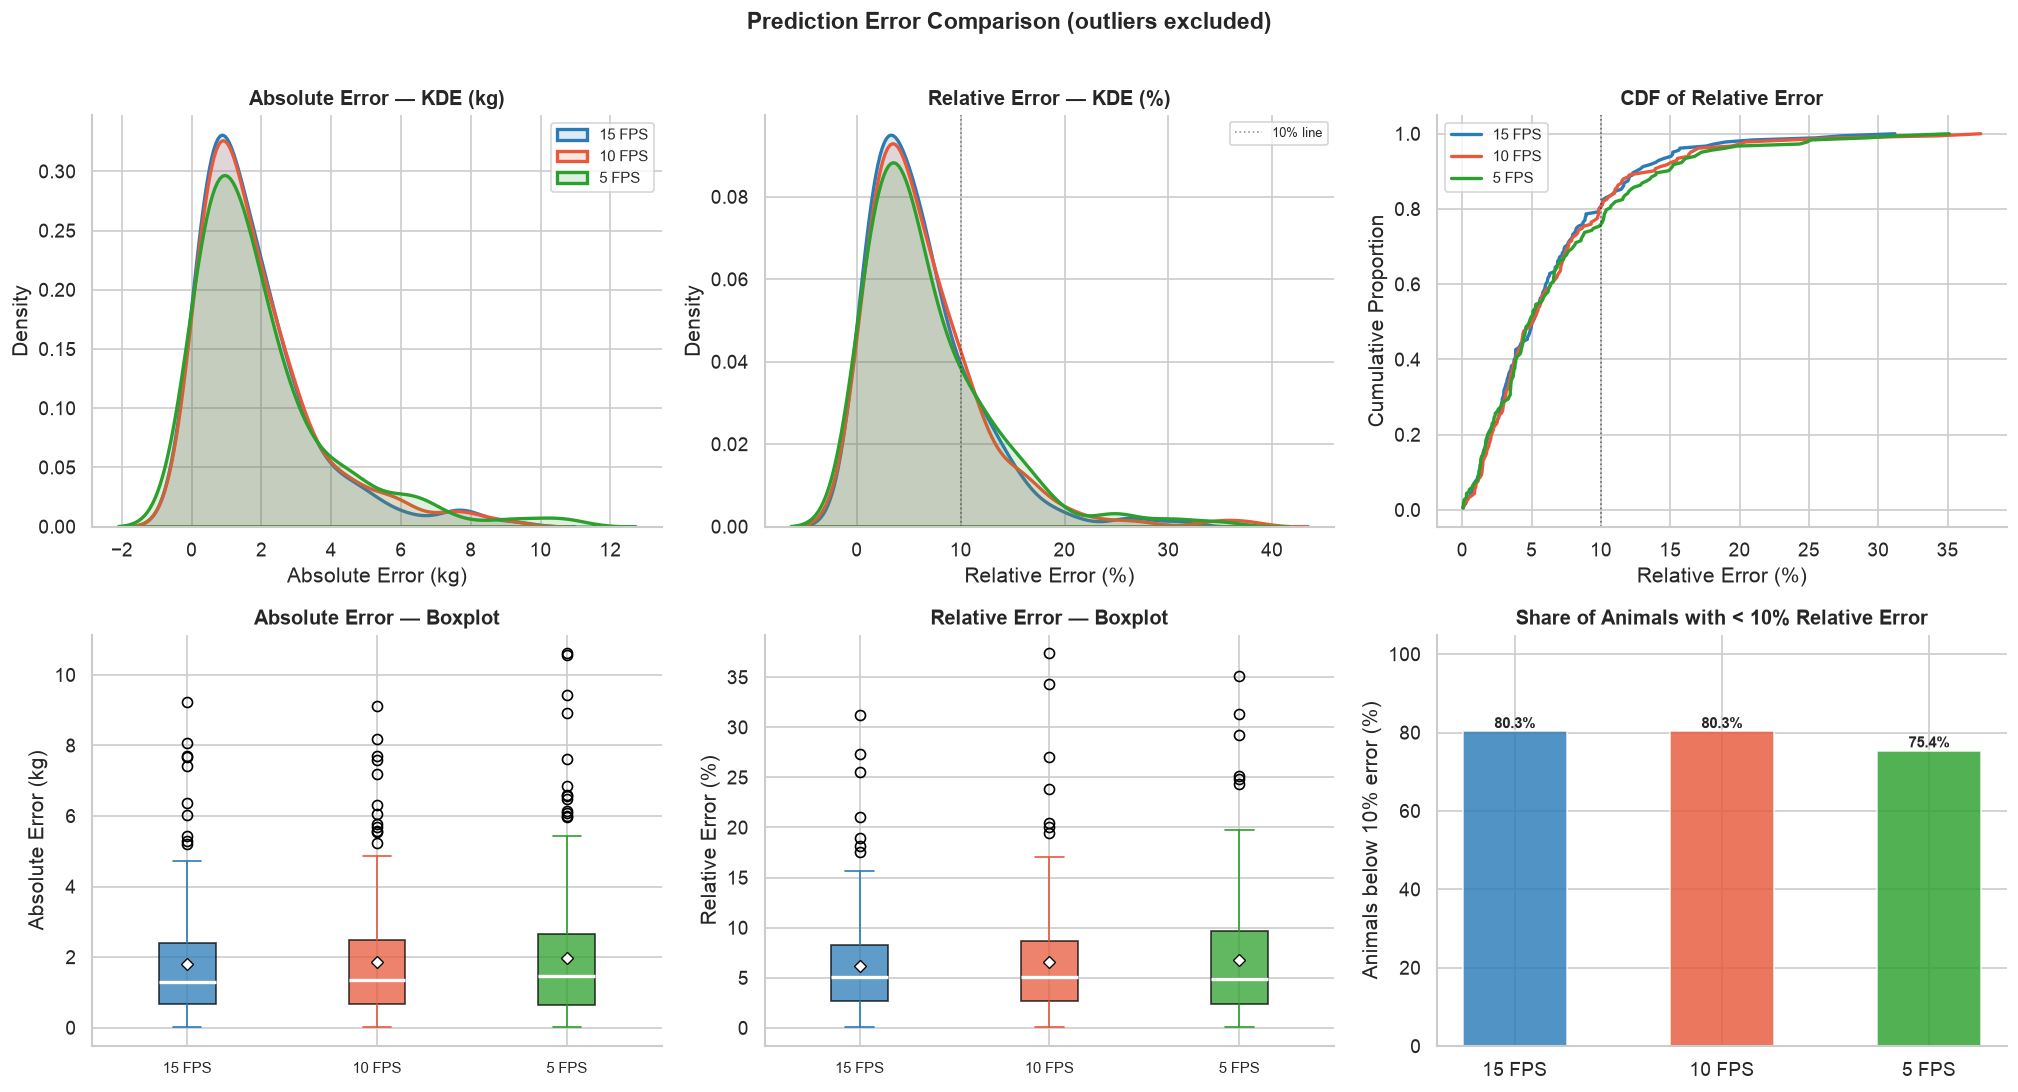

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for run, color in zip(LOADED, RUN_COLORS):
    drc = run["df_report"][~run["df_report"].is_outlier]
    sns.kdeplot(drc["abs_error"],      ax=axes[0][0], color=color, lw=2, fill=True, alpha=0.15, label=run["label"])
    sns.kdeplot(drc["rel_error_pct"],  ax=axes[0][1], color=color, lw=2, fill=True, alpha=0.15)

axes[0][0].set_title("Absolute Error — KDE (kg)")
axes[0][0].set_xlabel("Absolute Error (kg)")
axes[0][0].legend(fontsize=9)
axes[0][1].set_title("Relative Error — KDE (%)")
axes[0][1].set_xlabel("Relative Error (%)")
axes[0][1].axvline(10, color="black", ls=":", lw=1, alpha=0.4, label="10% line")
axes[0][1].legend(fontsize=8)

# ── CDF of relative error ─────────────────────────────────────────────────
ax = axes[0][2]
for run, color in zip(LOADED, RUN_COLORS):
    drc = run["df_report"][~run["df_report"].is_outlier]
    sorted_err = np.sort(drc["rel_error_pct"])
    cdf = np.arange(1, len(sorted_err)+1) / len(sorted_err)
    ax.plot(sorted_err, cdf, color=color, lw=2, label=run["label"])
ax.axvline(10, color="black", ls=":", lw=1, alpha=0.5)
ax.set_xlabel("Relative Error (%)")
ax.set_ylabel("Cumulative Proportion")
ax.set_title("CDF of Relative Error")
ax.legend(fontsize=9)

# ── Box plots ─────────────────────────────────────────────────────────────
def boxplot_err(ax, metric, ylabel, title):
    data   = [run["df_report"][~run["df_report"].is_outlier][metric].values for run in LOADED]
    labels = [r["label"] for r in LOADED]
    bp = ax.boxplot(data, patch_artist=True,
                    medianprops=dict(color="white", lw=2))
    for patch, color in zip(bp["boxes"], RUN_COLORS[:n]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for whisker, color in zip(bp["whiskers"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        whisker.set_color(color)
    for cap, color in zip(bp["caps"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        cap.set_color(color)
    ax.set_xticks(range(1, n+1)); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title)
    for i, d in enumerate(data, 1):
        ax.plot(i, np.mean(d), "D", color="white", ms=5, zorder=5,
                markeredgecolor="black", markeredgewidth=0.8)

boxplot_err(axes[1][0], "abs_error",     "Absolute Error (kg)", "Absolute Error — Boxplot")
boxplot_err(axes[1][1], "rel_error_pct", "Relative Error (%)",  "Relative Error — Boxplot")

# ── Bar: % of animals below 10% error ─────────────────────────────────────
ax = axes[1][2]
pct_under10 = [
    (run["df_report"][~run["df_report"].is_outlier]["rel_error_pct"] < 10).mean() * 100
    for run in LOADED
]
bars = ax.bar([r["label"] for r in LOADED], pct_under10,
              color=RUN_COLORS[:n], alpha=0.82, edgecolor="white", width=0.5)
for bar, val in zip(bars, pct_under10):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_ylabel("Animals below 10% error (%)")
ax.set_title("Share of Animals with < 10% Relative Error")
ax.set_ylim(0, 105)

plt.suptitle("Prediction Error Comparison (outliers excluded)", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cmp_prediction_error.png", dpi=120, bbox_inches="tight")
plt.show()


## 6. Core Tradeoff: Suited Frames → Error (per Run)
Does a higher FPS actually yield more suited frames *and* lower error? This section tests that chain.


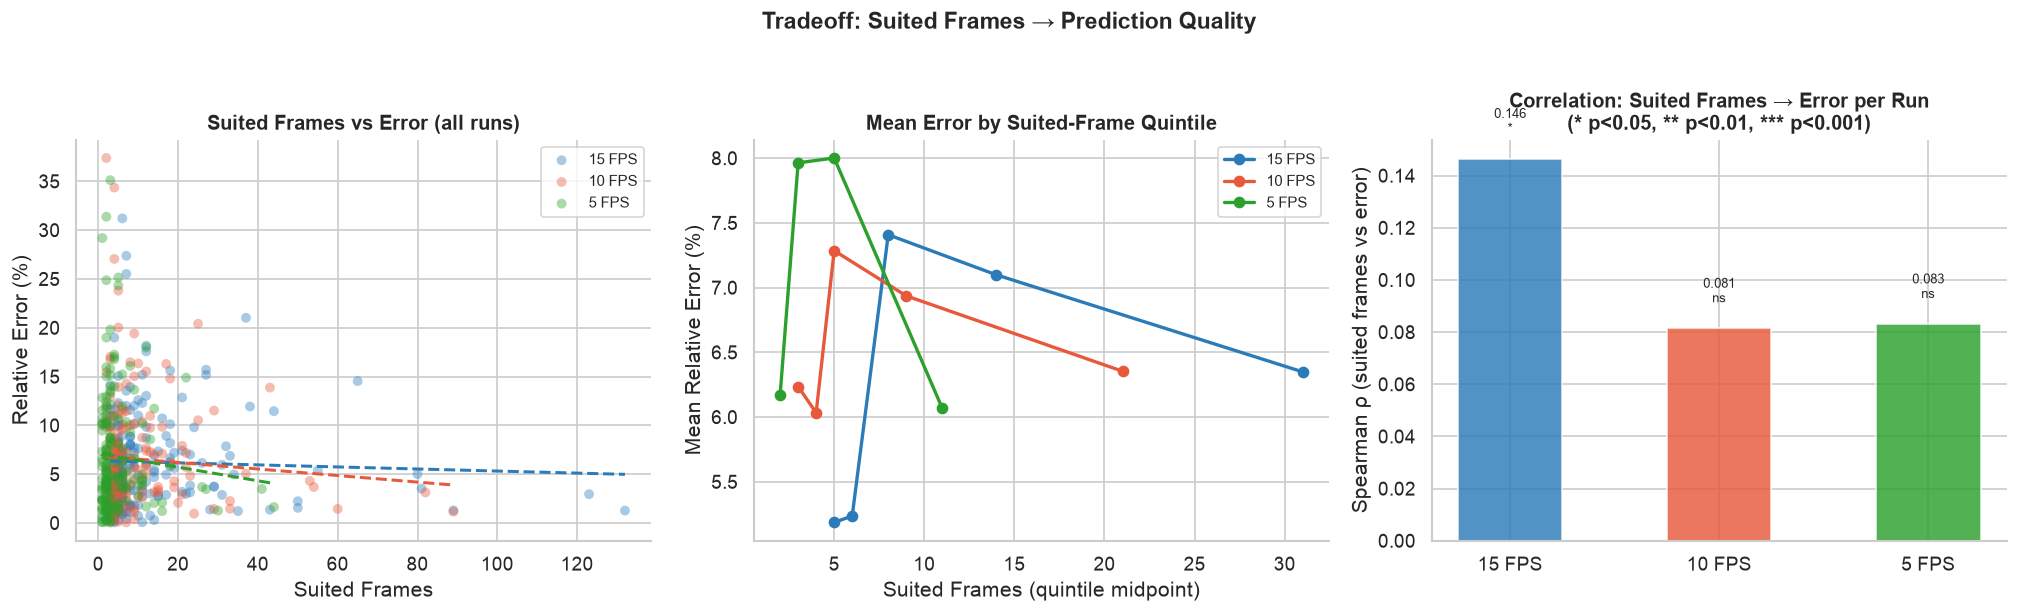

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# ── (A) Scatter: suited_pred vs rel_error (one panel per run, overlaid) ──
ax = axes[0]
for run, color in zip(LOADED, RUN_COLORS):
    drc = run["df_report"][~run["df_report"].is_outlier]
    ax.scatter(drc["suited_pred"], drc["rel_error_pct"],
               alpha=0.40, s=35, color=color, label=run["label"], edgecolors="none")
    # Trend line
    x, y = drc["suited_pred"], drc["rel_error_pct"]
    m, b, r, *_ = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 100)
    ax.plot(xline, m*xline+b, color=color, lw=1.8, ls="--")

ax.set_xlabel("Suited Frames")
ax.set_ylabel("Relative Error (%)")
ax.set_title("Suited Frames vs Error (all runs)")
ax.legend(fontsize=9)

# ── (B) Binned mean error by suited-frame quintile, per run ──────────────
ax = axes[1]
for run, color in zip(LOADED, RUN_COLORS):
    drc = run["df_report"][~run["df_report"].is_outlier].copy()
    drc["suited_bin"] = pd.qcut(drc["suited_pred"], q=5, duplicates="drop", labels=False)
    agg = drc.groupby("suited_bin", observed=True).agg(
        mean_err=("rel_error_pct", "mean"),
        mid=("suited_pred", "median")
    ).reset_index()
    ax.plot(agg["mid"], agg["mean_err"], "o-", color=color, lw=2, ms=6, label=run["label"])

ax.set_xlabel("Suited Frames (quintile midpoint)")
ax.set_ylabel("Mean Relative Error (%)")
ax.set_title("Mean Error by Suited-Frame Quintile")
ax.legend(fontsize=9)

# ── (C) Spearman ρ per run (bar) ─────────────────────────────────────────
ax = axes[2]
rhos, pvals = [], []
for run in LOADED:
    drc = run["df_report"][~run["df_report"].is_outlier]
    rho, pv = spearmanr(drc["suited_pred"], drc["rel_error_pct"])
    rhos.append(rho); pvals.append(pv)

bars = ax.bar([r["label"] for r in LOADED], rhos,
              color=RUN_COLORS[:n], alpha=0.82, edgecolor="white", width=0.5)
for bar, rho, pv in zip(bars, rhos, pvals):
    sig = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "ns"))
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + (0.01 if rho >= 0 else -0.03),
            f"{rho:.3f}\n{sig}", ha="center", fontsize=8)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("Spearman ρ (suited frames vs error)")
ax.set_title("Correlation: Suited Frames → Error per Run\n(* p<0.05, ** p<0.01, *** p<0.001)")

plt.suptitle("Tradeoff: Suited Frames → Prediction Quality", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cmp_tradeoff_suited_error.png", dpi=120, bbox_inches="tight")
plt.show()


## 7. FPS Yield Analysis — More Frames → More Suited?
Does a higher FPS actually produce a better suited ratio, or does the selector's conversion rate degrade?


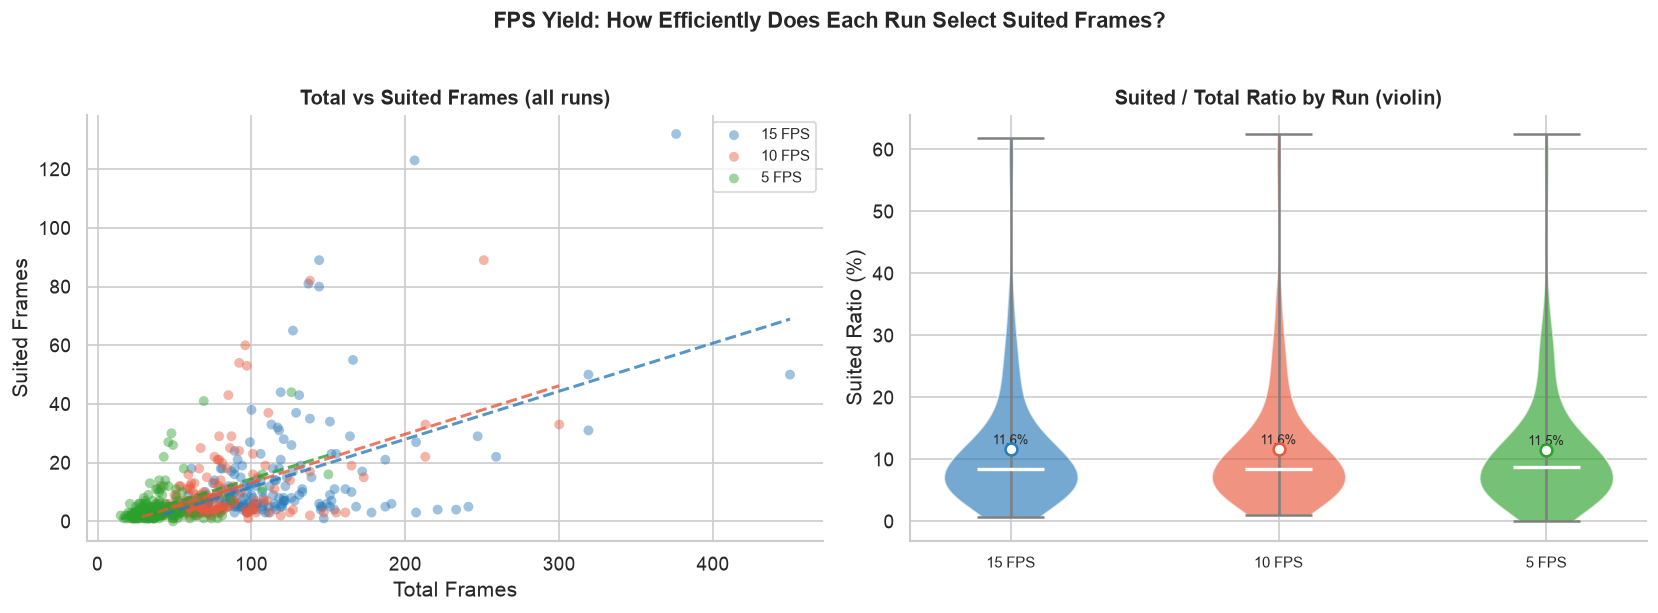

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── (A) Total frames vs suited, per run ─────────────────────────────────
ax = axes[0]
for run, color in zip(LOADED, RUN_COLORS):
    dr = run["df_report"]
    ax.scatter(dr["total_frames"], dr["suited_pred"],
               alpha=0.45, s=35, color=color, label=run["label"], edgecolors="none")
    m, b, r, *_ = stats.linregress(dr["total_frames"], dr["suited_pred"])
    xline = np.linspace(dr["total_frames"].min(), dr["total_frames"].max(), 100)
    ax.plot(xline, m*xline+b, color=color, lw=1.8, ls="--", alpha=0.8)

ax.set_xlabel("Total Frames")
ax.set_ylabel("Suited Frames")
ax.set_title("Total vs Suited Frames (all runs)")
ax.legend(fontsize=9)

# ── (B) Suited ratio by run (violin) ────────────────────────────────────
ax = axes[1]
plot_data  = [run["df_report"]["suited_pred"] / run["df_report"]["total_frames"] * 100 for run in LOADED]
plot_labels= [r["label"] for r in LOADED]
parts = ax.violinplot(plot_data, showmedians=True, showmeans=False)
for i, (pc, color) in enumerate(zip(parts["bodies"], RUN_COLORS[:n])):
    pc.set_facecolor(color); pc.set_alpha(0.65)
parts["cmedians"].set_color("white"); parts["cmedians"].set_lw(2)
for key in ["cbars","cmins","cmaxes"]:
    parts[key].set_colors(["grey"]*n)
ax.set_xticks(range(1, n+1))
ax.set_xticklabels(plot_labels, fontsize=9)
ax.set_ylabel("Suited Ratio (%)")
ax.set_title("Suited / Total Ratio by Run (violin)")

# Overlay means
for i, (d, color) in enumerate(zip(plot_data, RUN_COLORS[:n]), 1):
    ax.scatter(i, np.mean(d), color="white", s=50, zorder=5,
               edgecolors=color, linewidths=1.5)
    ax.text(i, np.mean(d) + 0.8, f"{np.mean(d):.1f}%", ha="center", fontsize=8)

plt.suptitle("FPS Yield: How Efficiently Does Each Run Select Suited Frames?",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cmp_fps_yield.png", dpi=120, bbox_inches="tight")
plt.show()


## 8. Selector Quality Comparison — F1, Precision & Recall

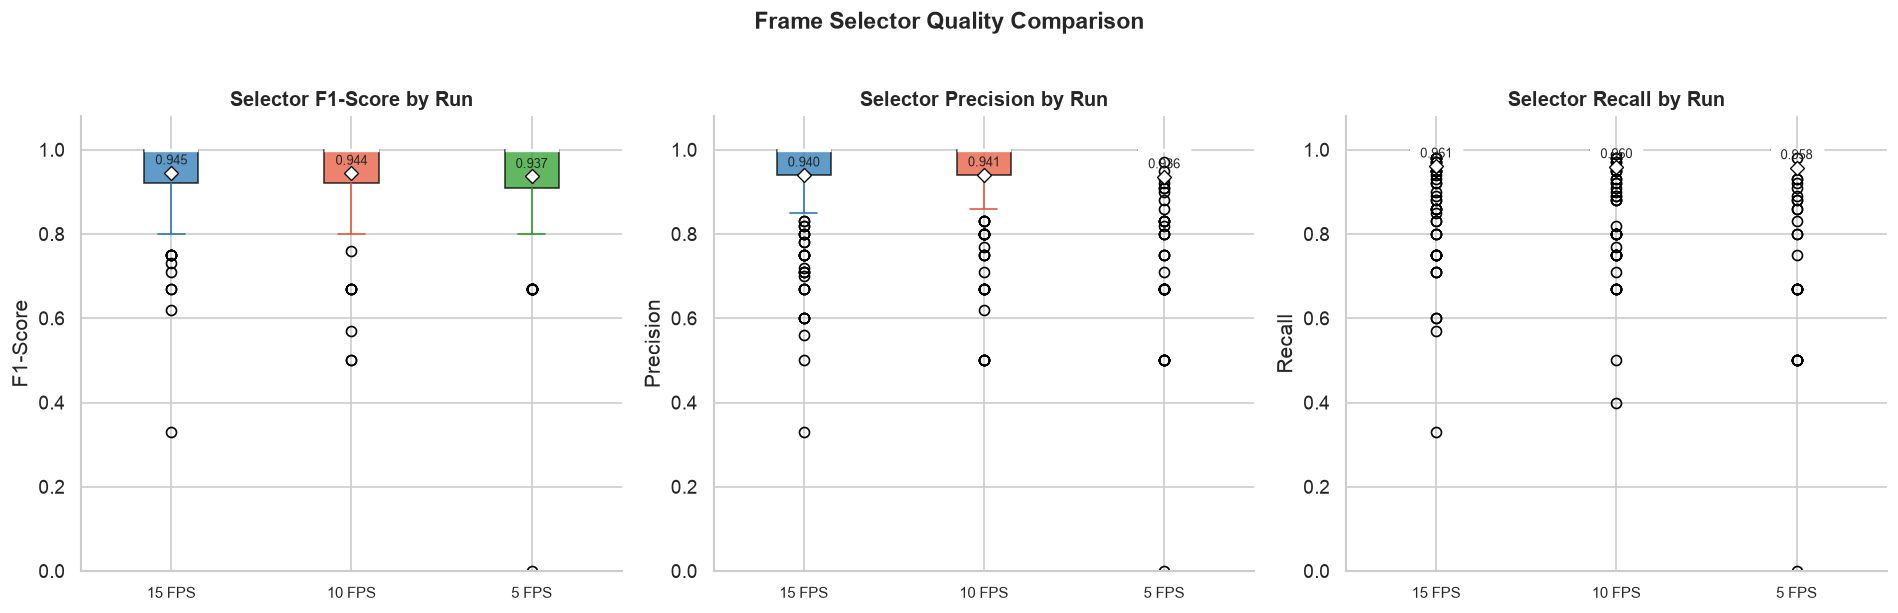

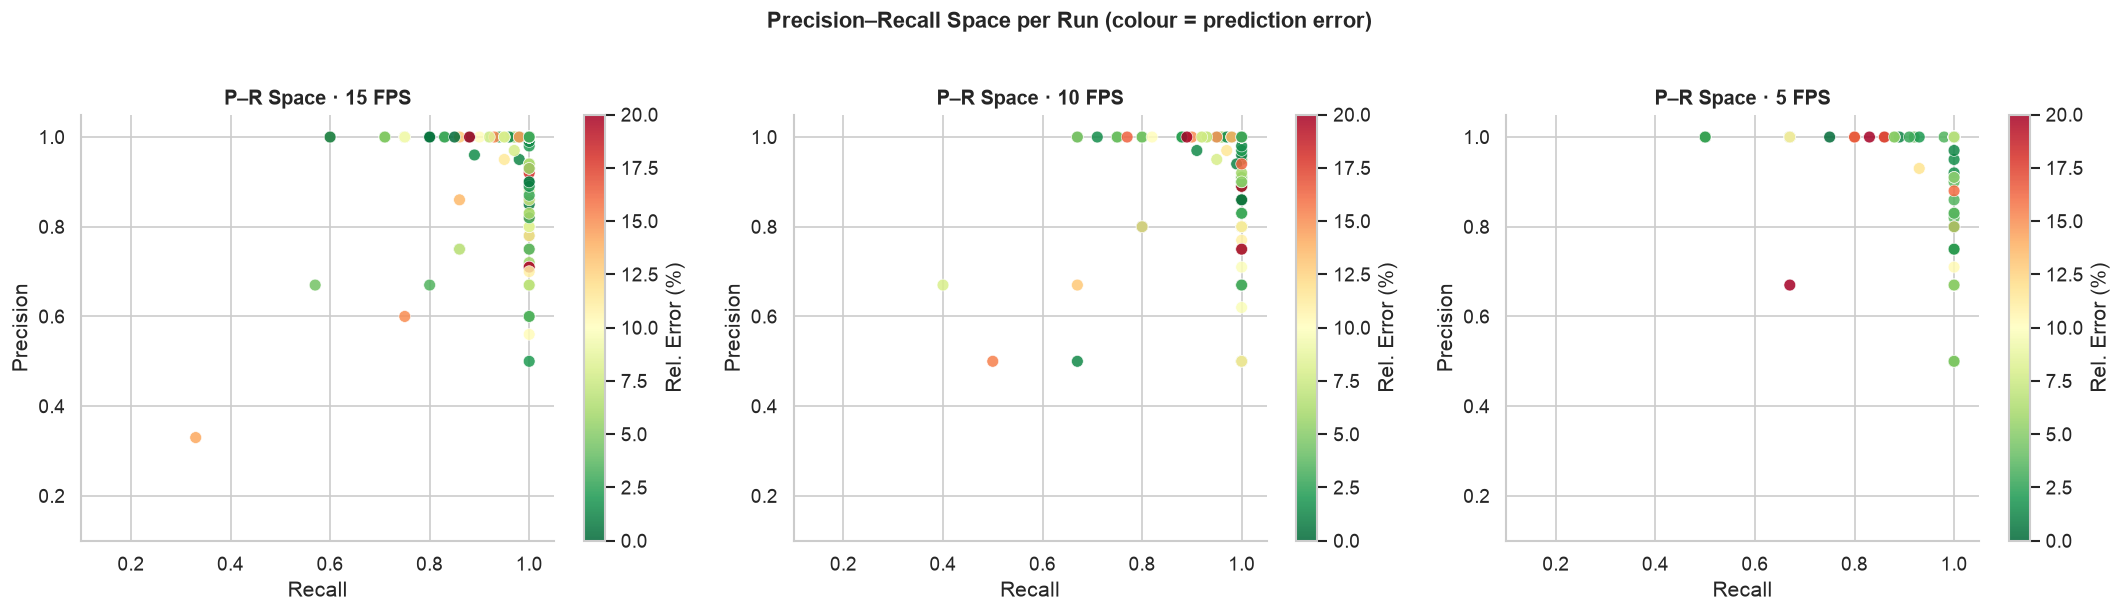

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for metric, ax, title in zip(
    ["f1", "precision", "recall"],
    axes,
    ["F1-Score", "Precision", "Recall"]
):
    plot_data   = [run["df_report"][~run["df_report"].is_outlier][metric].values for run in LOADED]
    plot_labels = [r["label"] for r in LOADED]
    bp = ax.boxplot(plot_data, patch_artist=True, medianprops=dict(color="white", lw=2))
    for patch, color in zip(bp["boxes"], RUN_COLORS[:n]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for whisker, color in zip(bp["whiskers"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        whisker.set_color(color)
    for cap, color in zip(bp["caps"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        cap.set_color(color)
    ax.set_xticks(range(1, n+1)); ax.set_xticklabels(plot_labels, fontsize=9)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel(title)
    ax.set_title(f"Selector {title} by Run")
    for i, d in enumerate(plot_data, 1):
        ax.plot(i, np.mean(d), "D", color="white", ms=6, zorder=5,
                markeredgecolor="black", markeredgewidth=0.8)
        ax.text(i, np.mean(d) + 0.02, f"{np.mean(d):.3f}", ha="center", fontsize=8)

plt.suptitle("Frame Selector Quality Comparison", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cmp_selector_quality.png", dpi=120, bbox_inches="tight")
plt.show()

# Precision-Recall scatter per run
fig, axes = plt.subplots(1, n, figsize=(6*n, 5), squeeze=False)
for ax, run, color in zip(axes[0], LOADED, RUN_COLORS):
    drc = run["df_report"][~run["df_report"].is_outlier]
    sc = ax.scatter(drc["recall"], drc["precision"],
                    c=drc["rel_error_pct"], cmap="RdYlGn_r",
                    vmin=0, vmax=20, s=50, edgecolors="white", lw=0.4, alpha=0.85)
    plt.colorbar(sc, ax=ax, label="Rel. Error (%)")
    ax.set_xlim(0.1, 1.05); ax.set_ylim(0.1, 1.05)
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"P–R Space · {run['label']}")

plt.suptitle("Precision–Recall Space per Run (colour = prediction error)",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cmp_precision_recall.png", dpi=120, bbox_inches="tight")
plt.show()


## 9. Timing Comparison — Lead Time, Latency & Processing Delay

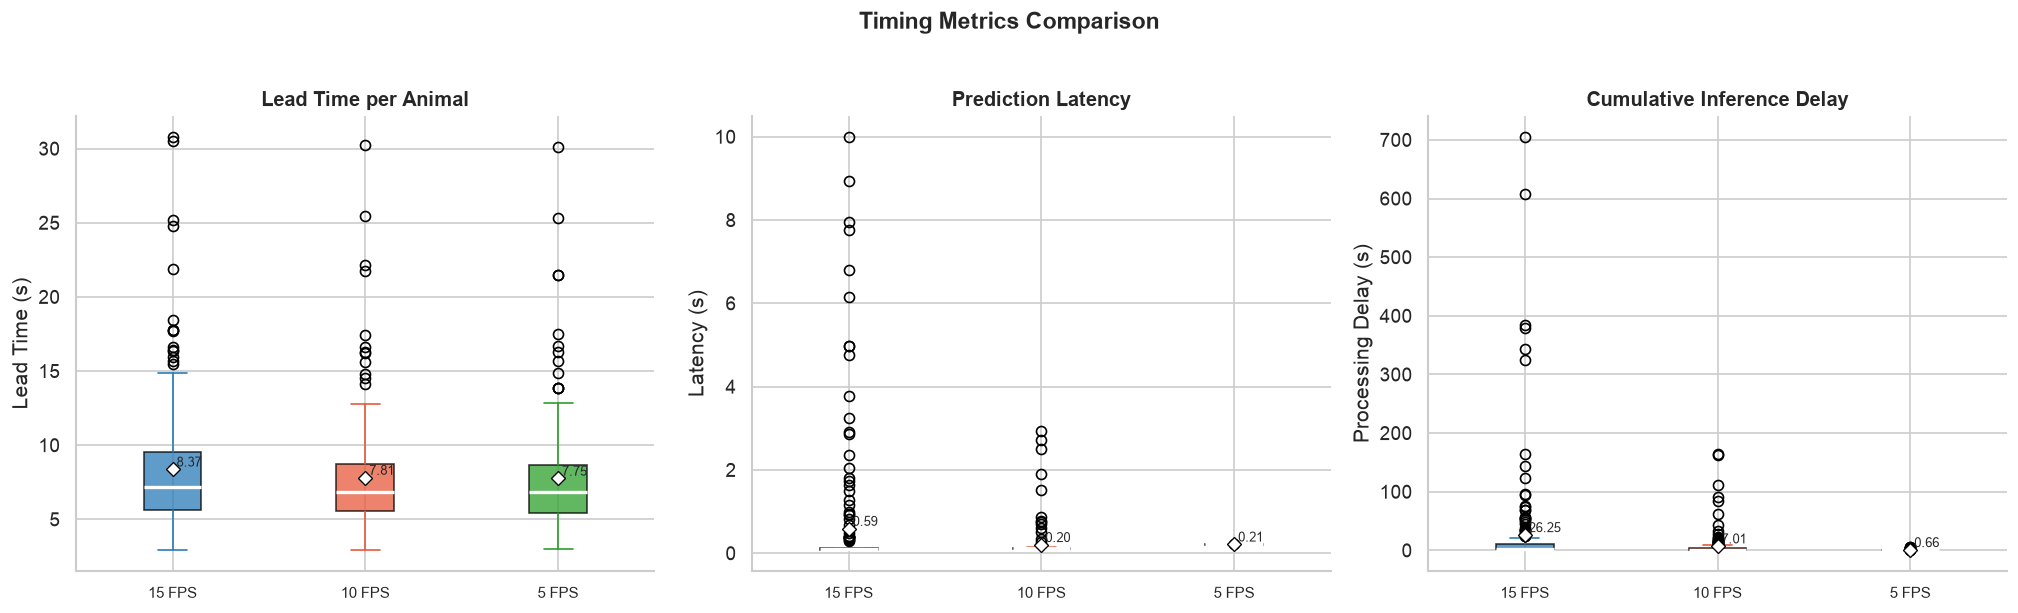

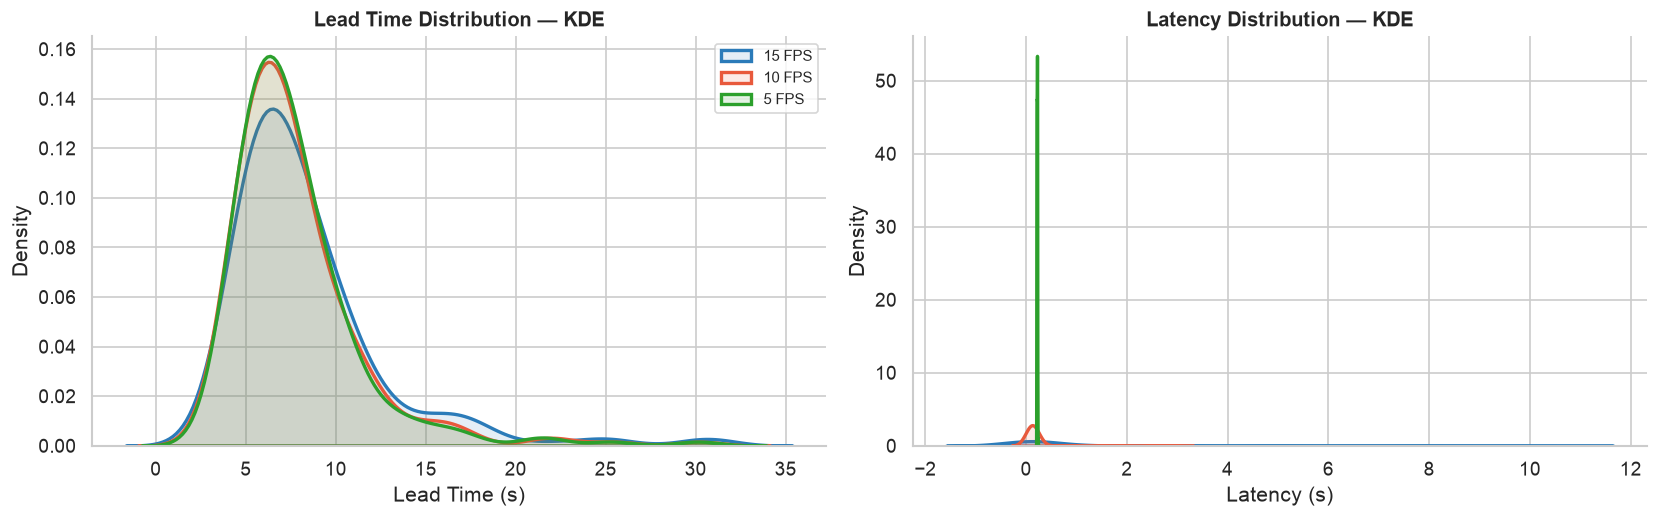

In [12]:
timing_metrics = [
    ("by_animal_lead_time_sec",             "Lead Time (s)",         "Lead Time per Animal"),
    ("by_animal_latency_sec",               "Latency (s)",           "Prediction Latency"),
    ("by_animal_processing_delay_sec",      "Processing Delay (s)",  "Cumulative Inference Delay"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (col, ylabel, title) in zip(axes, timing_metrics):
    plot_data   = [run["df_animals"][col].dropna().values for run in LOADED]
    plot_labels = [r["label"] for r in LOADED]
    bp = ax.boxplot(plot_data, patch_artist=True, medianprops=dict(color="white", lw=2))
    for patch, color in zip(bp["boxes"], RUN_COLORS[:n]):
        patch.set_facecolor(color); patch.set_alpha(0.75)
    for whisker, color in zip(bp["whiskers"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        whisker.set_color(color)
    for cap, color in zip(bp["caps"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
        cap.set_color(color)
    ax.set_xticks(range(1, n+1)); ax.set_xticklabels(plot_labels, fontsize=9)
    ax.set_ylabel(ylabel); ax.set_title(title)
    for i, d in enumerate(plot_data, 1):
        ax.plot(i, np.mean(d), "D", color="white", ms=6, zorder=5,
                markeredgecolor="black", markeredgewidth=0.8)
        ax.text(i, np.mean(d), f" {np.mean(d):.2f}", ha="left", fontsize=8, va="bottom")

plt.suptitle("Timing Metrics Comparison", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cmp_timing.png", dpi=120, bbox_inches="tight")
plt.show()

# ── KDE overlay of lead time ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for run, color in zip(LOADED, RUN_COLORS):
    da = run["df_animals"]
    sns.kdeplot(da["by_animal_lead_time_sec"].dropna(),
                ax=axes[0], color=color, lw=2, fill=True, alpha=0.12, label=run["label"])
    sns.kdeplot(da["by_animal_latency_sec"].dropna(),
                ax=axes[1], color=color, lw=2, fill=True, alpha=0.12)

axes[0].set_title("Lead Time Distribution — KDE"); axes[0].set_xlabel("Lead Time (s)"); axes[0].legend(fontsize=9)
axes[1].set_title("Latency Distribution — KDE");   axes[1].set_xlabel("Latency (s)")

plt.tight_layout()
plt.savefig("cmp_timing_kde.png", dpi=120, bbox_inches="tight")
plt.show()


## 10. Resource Telemetry Comparison — CPU, RAM, Temperature

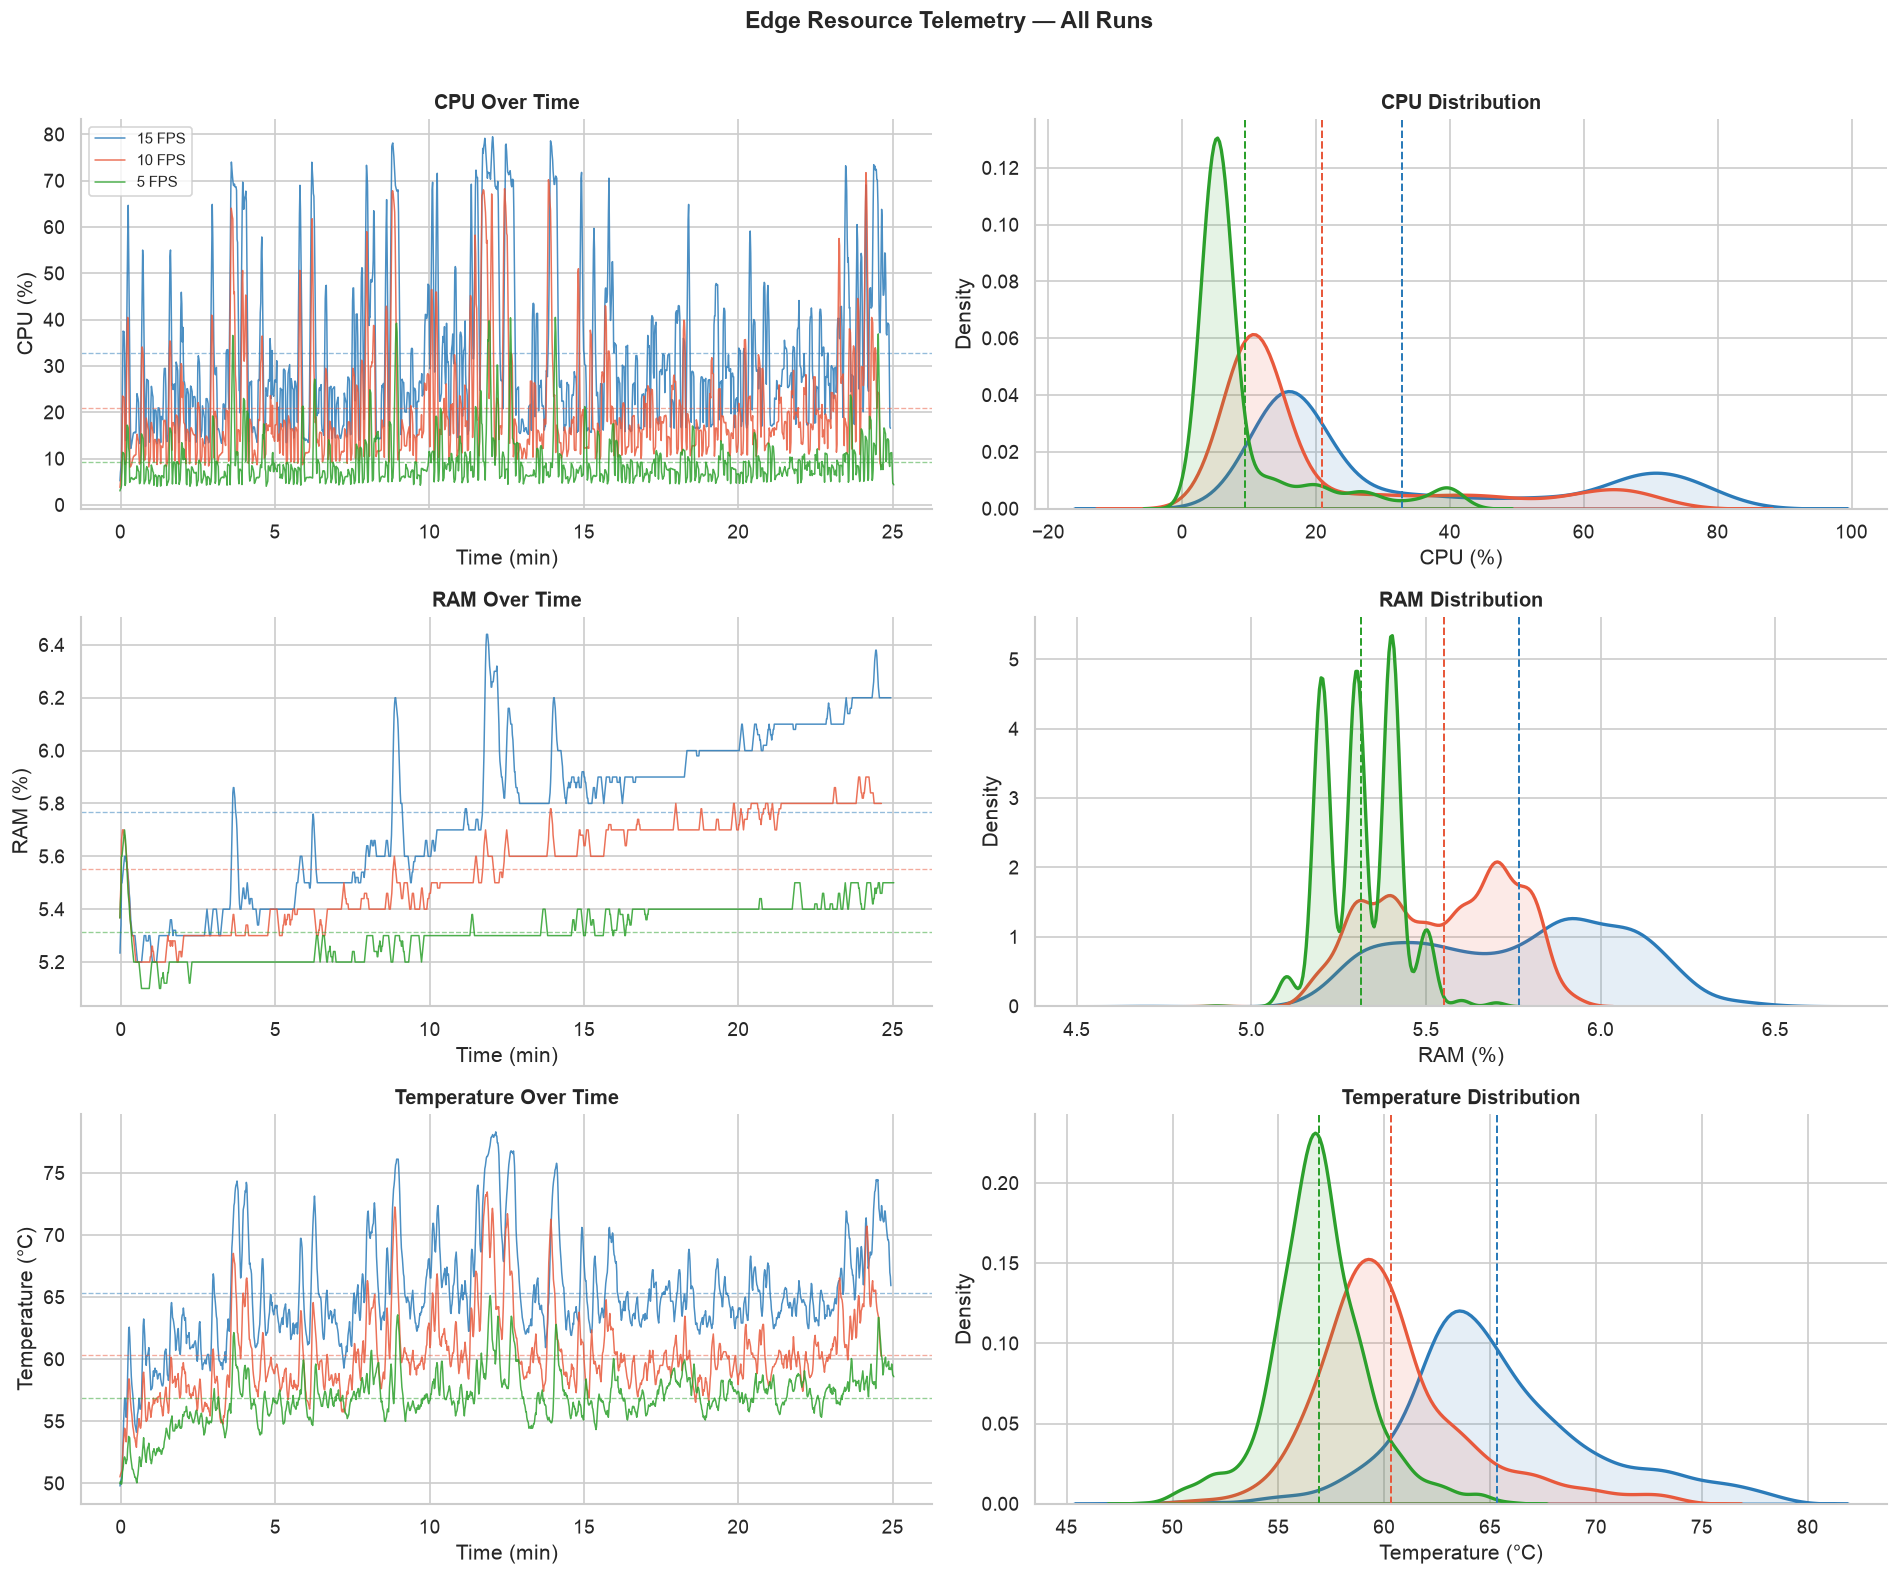

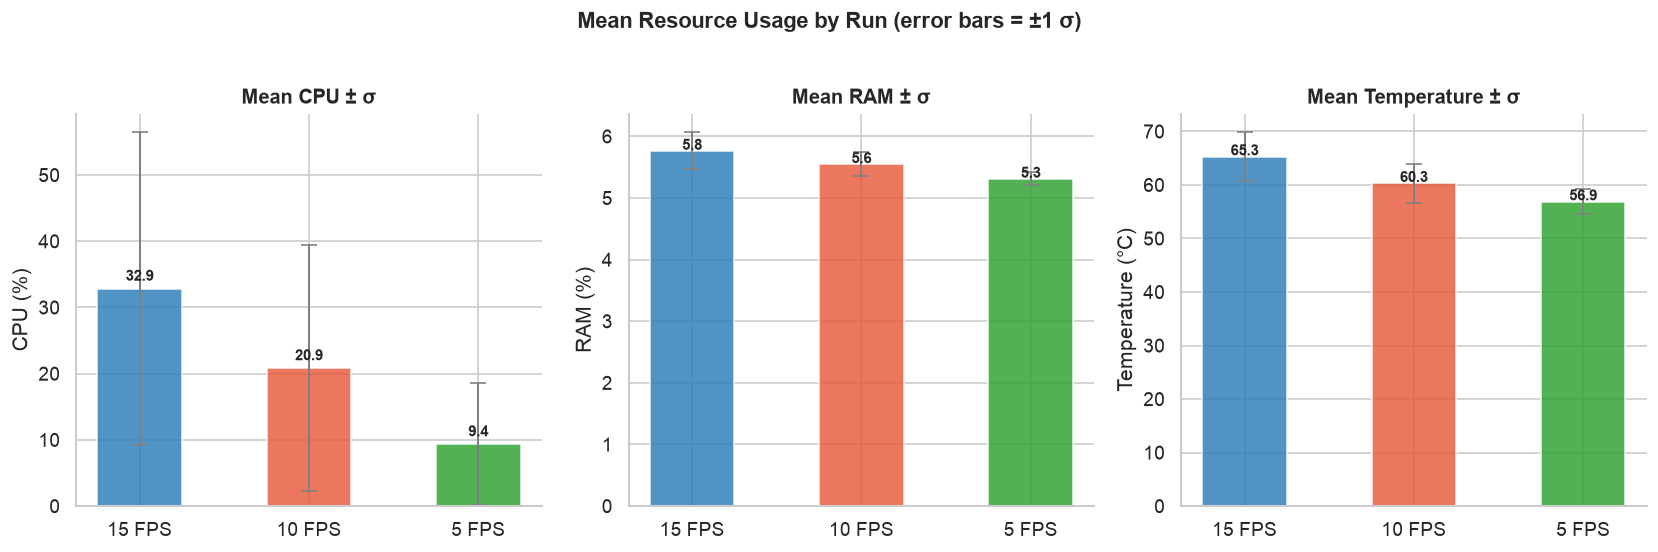

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(16, 13))
row_cfg = [
    ("df_cpu",  "cpu_mean",    "CPU (%)",         "CPU"),
    ("df_mem",  "percent",     "RAM (%)",          "RAM"),
    ("df_temp", "temperature", "Temperature (°C)", "Temperature"),
]

for row_idx, (df_key, col, ylabel, label_prefix) in enumerate(row_cfg):
    ax_time = axes[row_idx][0]
    ax_dist = axes[row_idx][1]

    for run, color in zip(LOADED, RUN_COLORS):
        df_src = run[df_key].copy()
        t0 = run["df_animals"]["first_image_capture_time"].min()
        df_src["t_min"] = (df_src["timestamp"] - t0).dt.total_seconds() / 60

        # Time series (rolling mean to reduce noise on long runs)
        roll = df_src[col].rolling(5, center=True, min_periods=1).mean()
        ax_time.plot(df_src["t_min"], roll, color=color, lw=0.9, alpha=0.85, label=run["label"])
        ax_time.axhline(df_src[col].mean(), color=color, ls="--", lw=0.8, alpha=0.5)

        # Distribution
        sns.kdeplot(df_src[col], ax=ax_dist, color=color, lw=2, fill=True, alpha=0.12)
        ax_dist.axvline(df_src[col].mean(), color=color, ls="--", lw=1.2)

    ax_time.set_ylabel(ylabel); ax_time.set_xlabel("Time (min)")
    ax_time.set_title(f"{label_prefix} Over Time")
    if row_idx == 0: ax_time.legend(fontsize=9)

    ax_dist.set_xlabel(ylabel)
    ax_dist.set_title(f"{label_prefix} Distribution")

plt.suptitle("Edge Resource Telemetry — All Runs", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cmp_resource_telemetry.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Summary bar chart of means ──────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, (df_key, col, ylabel, title) in zip(axes, row_cfg):
    means = [run[df_key][col].mean() for run in LOADED]
    stds  = [run[df_key][col].std()  for run in LOADED]
    bars = ax.bar([r["label"] for r in LOADED], means,
                  color=RUN_COLORS[:n], alpha=0.82, edgecolor="white", width=0.5,
                  yerr=stds, capsize=5, error_kw=dict(elinewidth=1.2, ecolor="grey"))
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.05,
                f"{mean:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.set_ylabel(ylabel); ax.set_title(f"Mean {title} ± σ")

plt.suptitle("Mean Resource Usage by Run (error bars = ±1 σ)", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("cmp_resource_means.png", dpi=120, bbox_inches="tight")
plt.show()


## 11. Resource Footprint per Animal
CPU and temperature *during* each animal's processing window, compared across runs.


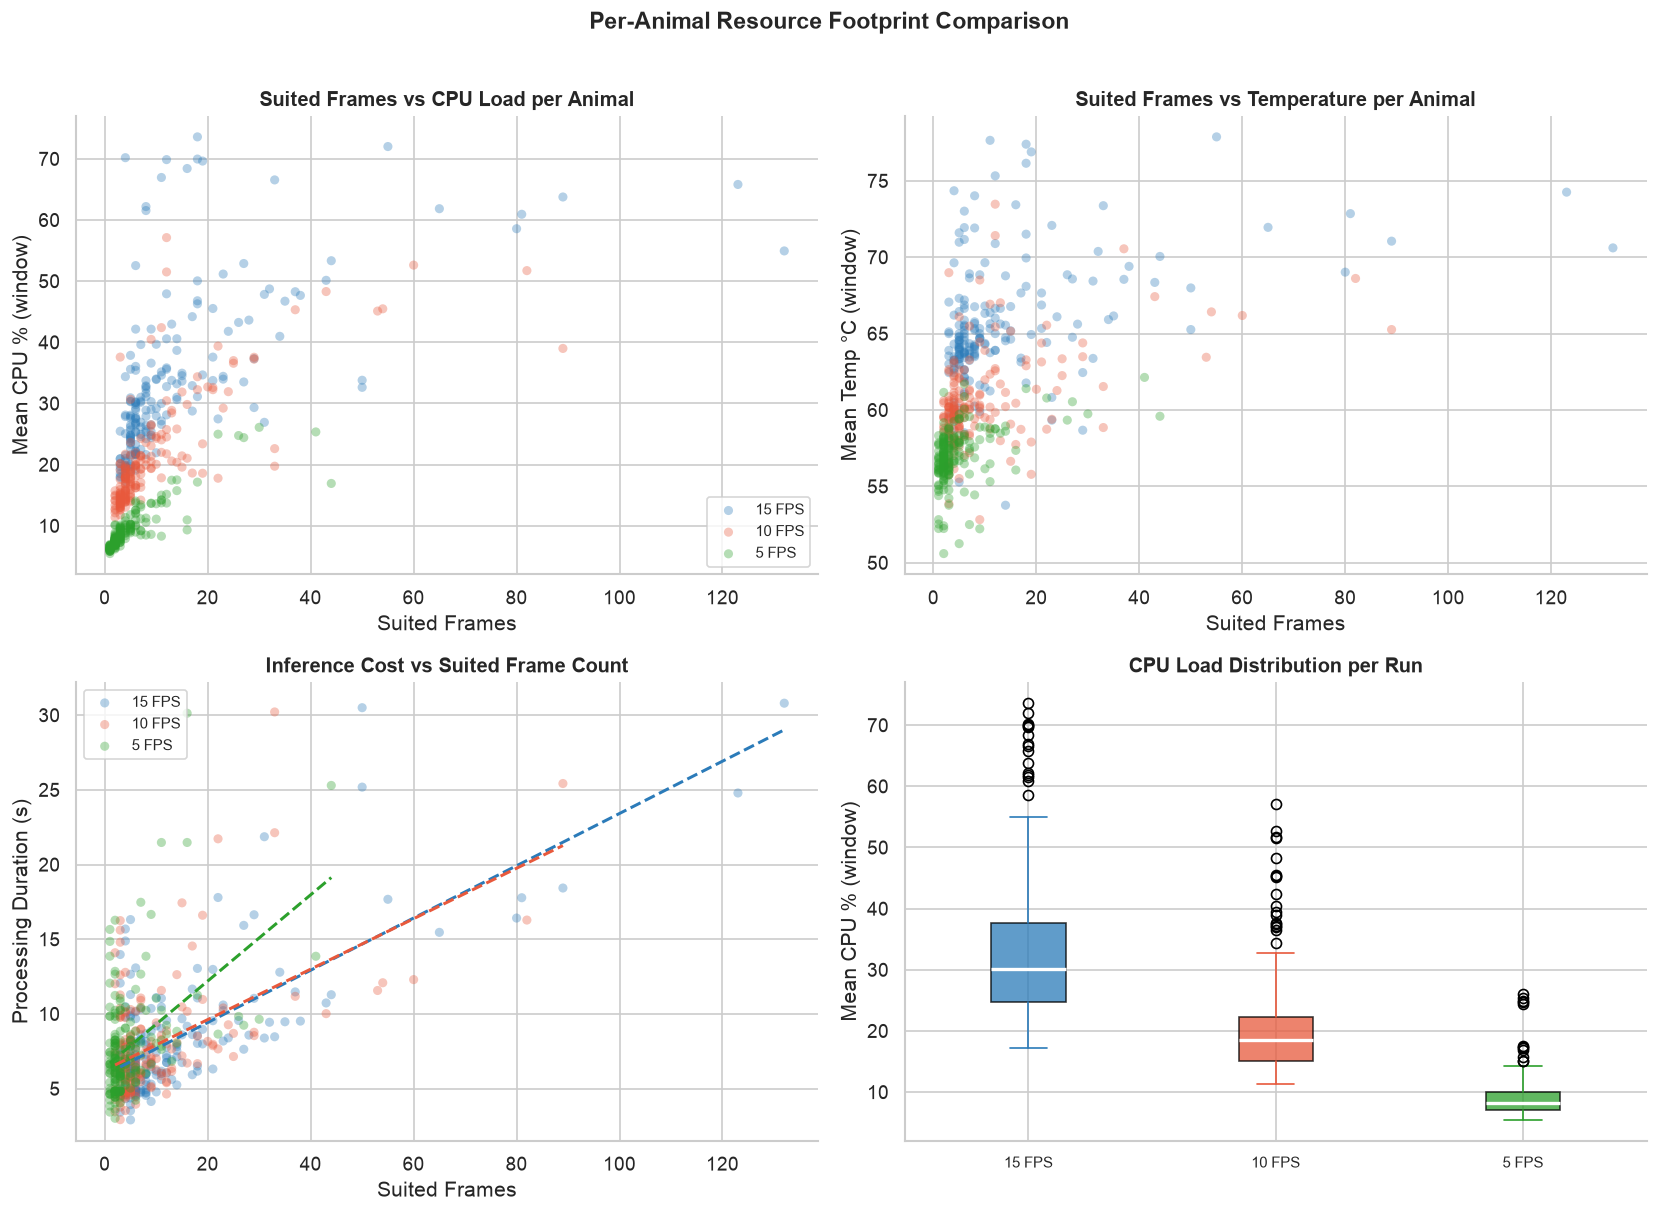

In [14]:
def compute_resource_per_animal(run):
    da      = run["df_animals"]
    df_cpu  = run["df_cpu"]
    df_temp = run["df_temp"]
    dr      = run["df_report"]
    rows    = []
    for _, row in da.iterrows():
        t0, t1 = row["first_image_capture_time"], row["weight_prediction_final"]
        if pd.isna(t0) or pd.isna(t1):
            continue
        mc = (df_cpu["timestamp"]  >= t0) & (df_cpu["timestamp"]  <= t1)
        mt = (df_temp["timestamp"] >= t0) & (df_temp["timestamp"] <= t1)
        rows.append({
            "animal_id":       row["animal_id"],
            "suited_images":   row["suitable_images"],
            "total_of_images": row["total_of_images"],
            "duration_s":      (t1 - t0).total_seconds(),
            "cpu_mean":        df_cpu.loc[mc,  "cpu_mean"].mean(),
            "temp_mean":       df_temp.loc[mt, "temperature"].mean(),
        })
    df = pd.DataFrame(rows).dropna(subset=["cpu_mean"])
    df = df.merge(dr[["animal_id","rel_error_pct","is_outlier"]], on="animal_id", how="left")
    return df[~df.is_outlier.fillna(False)]


fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── (A) Suited frames vs CPU window (overlay) ────────────────────────────
ax = axes[0][0]
for run, color in zip(LOADED, RUN_COLORS):
    df_r = compute_resource_per_animal(run)
    ax.scatter(df_r["suited_images"], df_r["cpu_mean"],
               alpha=0.35, s=30, color=color, edgecolors="none", label=run["label"])
ax.set_xlabel("Suited Frames"); ax.set_ylabel("Mean CPU % (window)")
ax.set_title("Suited Frames vs CPU Load per Animal"); ax.legend(fontsize=9)

# ── (B) Suited frames vs temp window (overlay) ───────────────────────────
ax = axes[0][1]
for run, color in zip(LOADED, RUN_COLORS):
    df_r = compute_resource_per_animal(run)
    ax.scatter(df_r["suited_images"], df_r["temp_mean"],
               alpha=0.35, s=30, color=color, edgecolors="none")
ax.set_xlabel("Suited Frames"); ax.set_ylabel("Mean Temp °C (window)")
ax.set_title("Suited Frames vs Temperature per Animal")

# ── (C) Processing duration vs suited frames ──────────────────────────────
ax = axes[1][0]
for run, color in zip(LOADED, RUN_COLORS):
    df_r = compute_resource_per_animal(run)
    ax.scatter(df_r["suited_images"], df_r["duration_s"],
               alpha=0.35, s=30, color=color, edgecolors="none", label=run["label"])
    m, b, r, *_ = stats.linregress(df_r["suited_images"], df_r["duration_s"])
    xl = np.linspace(df_r["suited_images"].min(), df_r["suited_images"].max(), 100)
    ax.plot(xl, m*xl+b, color=color, lw=1.8, ls="--")
ax.set_xlabel("Suited Frames"); ax.set_ylabel("Processing Duration (s)")
ax.set_title("Inference Cost vs Suited Frame Count"); ax.legend(fontsize=9)

# ── (D) Box: CPU window distribution per run ─────────────────────────────
ax = axes[1][1]
res_data = [compute_resource_per_animal(run)["cpu_mean"].values for run in LOADED]
bp = ax.boxplot(res_data, patch_artist=True, medianprops=dict(color="white", lw=2))
for patch, color in zip(bp["boxes"], RUN_COLORS[:n]):
    patch.set_facecolor(color); patch.set_alpha(0.75)
for whisker, color in zip(bp["whiskers"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
    whisker.set_color(color)
for cap, color in zip(bp["caps"], sum([[c,c] for c in RUN_COLORS[:n]], [])):
    cap.set_color(color)
ax.set_xticks(range(1, n+1)); ax.set_xticklabels([r["label"] for r in LOADED], fontsize=9)
ax.set_ylabel("Mean CPU % (window)"); ax.set_title("CPU Load Distribution per Run")

plt.suptitle("Per-Animal Resource Footprint Comparison", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("cmp_resource_per_animal.png", dpi=120, bbox_inches="tight")
plt.show()


## 12. Outlier Analysis per Run

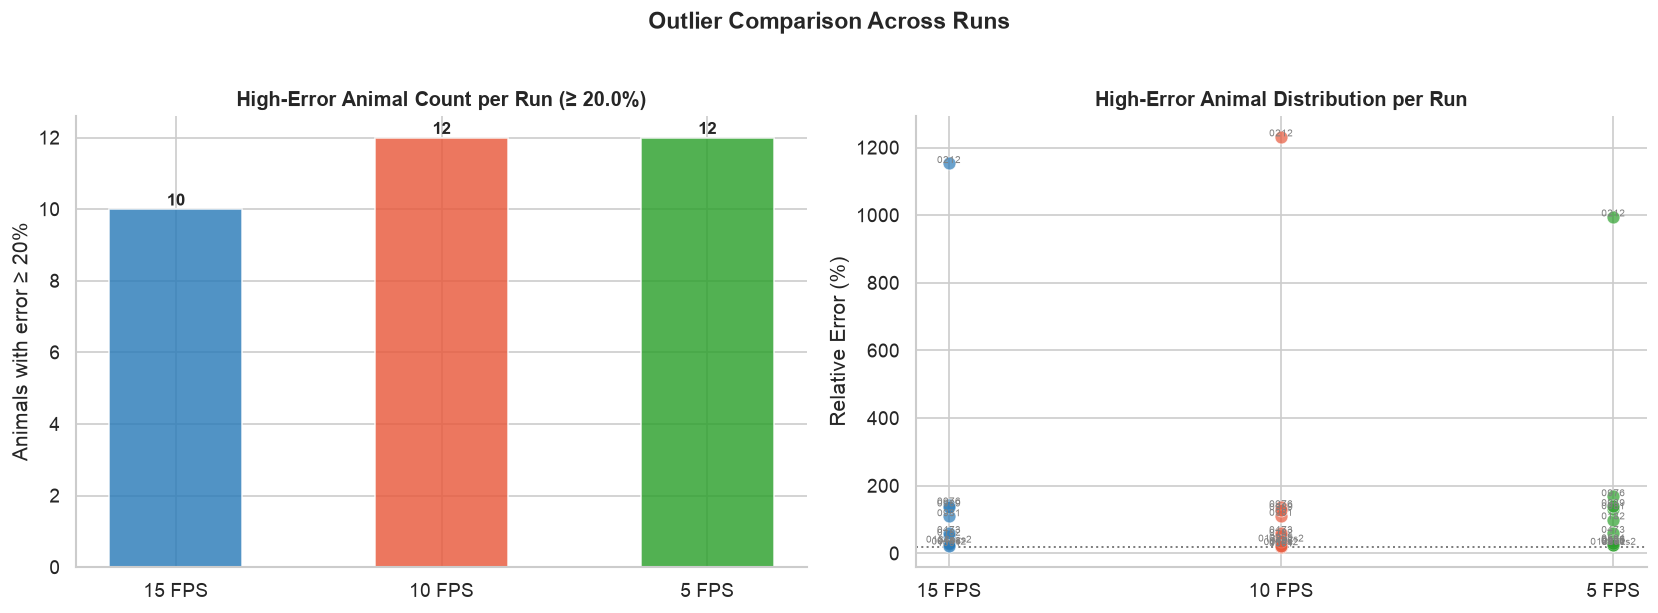


Animals consistently high-error (≥ 20%) across ALL runs:
   ['0138azs2', '0182', '0212', '0456', '0473', '0976', '0981', '0989']


In [15]:
HIGH_ERR = 20.0

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Count of high-error animals per run ─────────────────────────────────
ax = axes[0]
counts = [
    (run["df_report"]["rel_error_pct"] >= HIGH_ERR).sum()
    for run in LOADED
]
bars = ax.bar([r["label"] for r in LOADED], counts,
              color=RUN_COLORS[:n], alpha=0.82, edgecolor="white", width=0.5)
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(c), ha="center", fontsize=10, fontweight="bold")
ax.set_ylabel("Animals with error ≥ 20%")
ax.set_title(f"High-Error Animal Count per Run (≥ {HIGH_ERR}%)")

# ── Distribution of extreme errors per run ─────────────────────────────
ax = axes[1]
for run, color in zip(LOADED, RUN_COLORS):
    dr_high = run["df_report"][run["df_report"]["rel_error_pct"] >= HIGH_ERR]
    if len(dr_high) > 0:
        ax.scatter([run["label"]] * len(dr_high), dr_high["rel_error_pct"],
                   color=color, alpha=0.7, s=60, zorder=3, edgecolors="white", lw=0.5)
        for _, row in dr_high.iterrows():
            ax.text(run["label"], row["rel_error_pct"] + 0.5, row["animal_id"],
                    ha="center", fontsize=6, color="grey")

ax.axhline(HIGH_ERR, color="black", ls=":", lw=1.2, alpha=0.5)
ax.set_ylabel("Relative Error (%)"); ax.set_title("High-Error Animal Distribution per Run")

plt.suptitle("Outlier Comparison Across Runs", fontweight="bold", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("cmp_outliers.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Shared animals that are consistently high-error ──────────────────────
print("\nAnimals consistently high-error (≥ 20%) across ALL runs:")
high_sets = [set(run["df_report"][run["df_report"]["rel_error_pct"] >= HIGH_ERR]["animal_id"])
             for run in LOADED]
persistent = high_sets[0].intersection(*high_sets[1:]) if len(high_sets) > 1 else high_sets[0]
if persistent:
    print("  ", sorted(persistent))
else:
    print("  None — good sign: no animal is consistently mis-predicted.")


## 13. Summary Comparison Dashboard

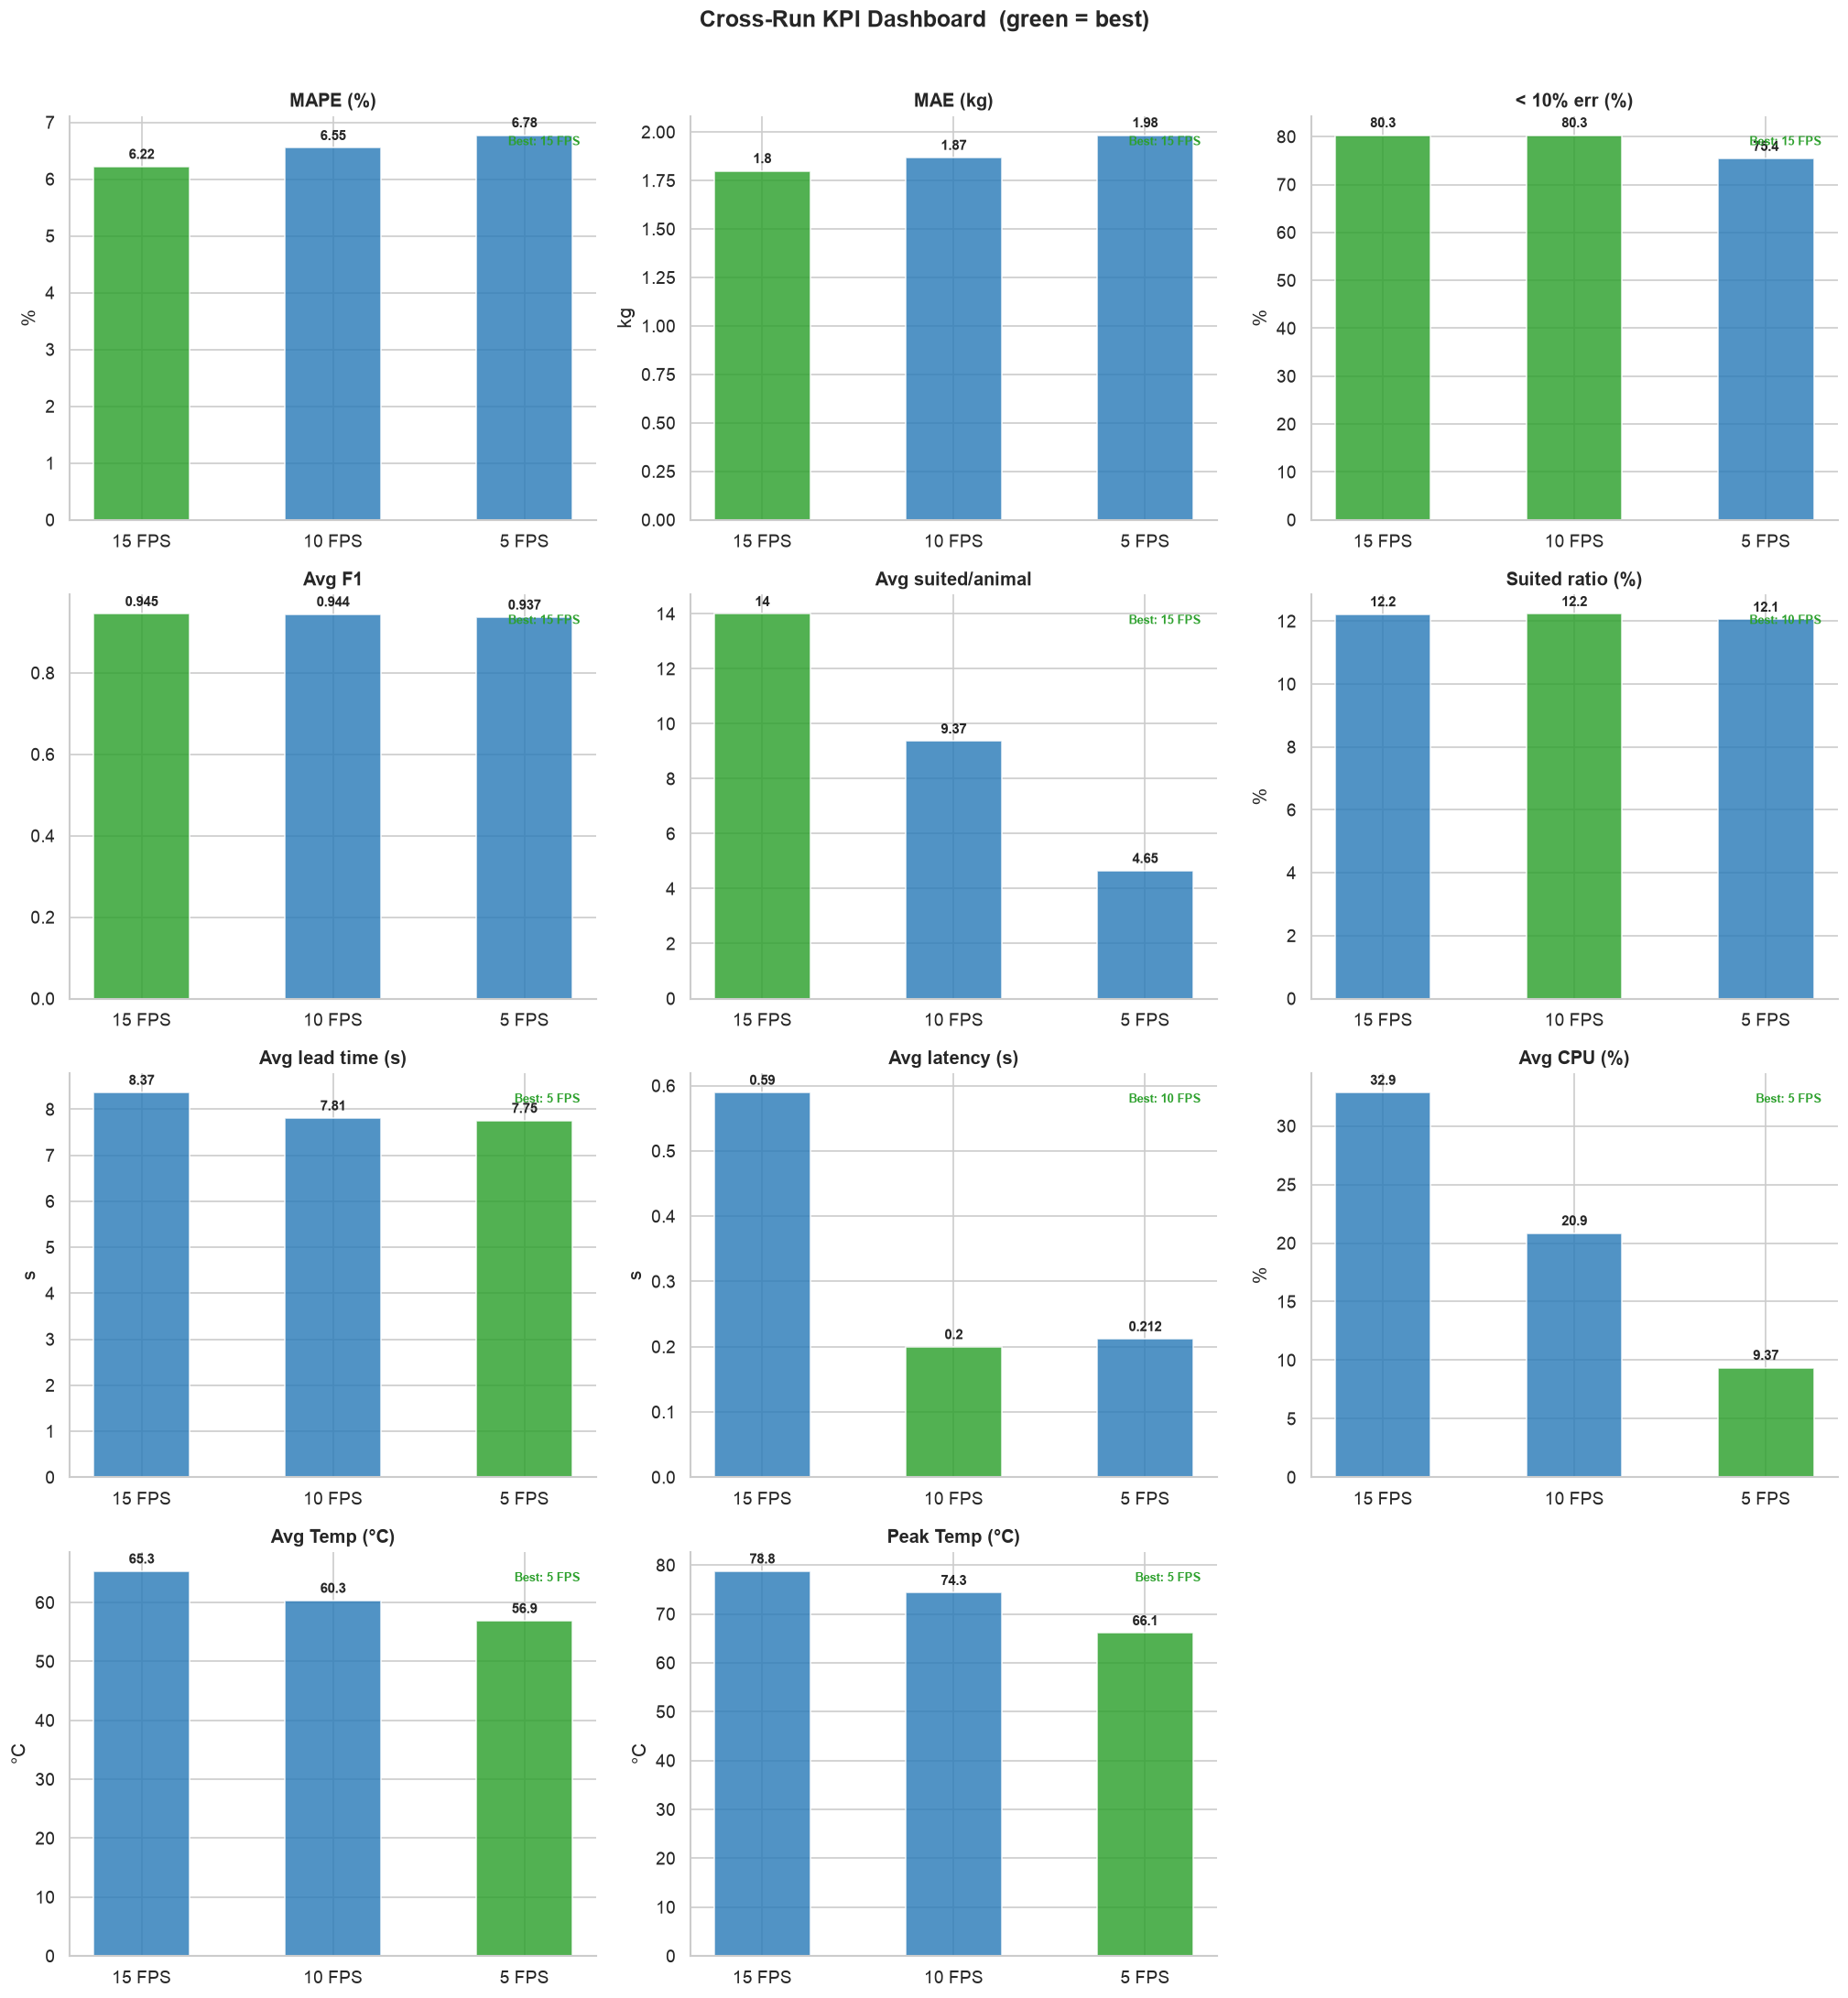

In [16]:
metrics_to_compare = [
    ("MAPE (%)",           lambda run: run["df_report"][~run["df_report"].is_outlier]["rel_error_pct"].mean(), "lower"),
    ("MAE (kg)",           lambda run: run["df_report"][~run["df_report"].is_outlier]["abs_error"].mean(), "lower"),
    ("< 10% err (%)",      lambda run: (run["df_report"][~run["df_report"].is_outlier]["rel_error_pct"] < 10).mean()*100, "higher"),
    ("Avg F1",             lambda run: run["df_report"][~run["df_report"].is_outlier]["f1"].mean(), "higher"),
    ("Avg suited/animal",  lambda run: run["df_animals"]["suitable_images"].mean(), "higher"),
    ("Suited ratio (%)",   lambda run: run["df_animals"]["suitable_images"].sum() / run["df_animals"]["total_of_images"].sum()*100, "higher"),
    ("Avg lead time (s)",  lambda run: run["df_animals"]["by_animal_lead_time_sec"].mean(), "lower"),
    ("Avg latency (s)",    lambda run: run["df_animals"]["by_animal_latency_sec"].mean(), "lower"),
    ("Avg CPU (%)",        lambda run: run["df_cpu"]["cpu_mean"].mean(), "lower"),
    ("Avg Temp (°C)",      lambda run: run["df_temp"]["temperature"].mean(), "lower"),
    ("Peak Temp (°C)",     lambda run: run["df_temp"]["temperature"].max(), "lower"),
]

ncols = 3
nrows = (len(metrics_to_compare) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(17, 4.5 * nrows))
axes = axes.flatten()

for ax, (metric_name, metric_fn, direction) in zip(axes, metrics_to_compare):
    values = []
    for run in LOADED:
        try:
            values.append(metric_fn(run))
        except Exception:
            values.append(np.nan)

    colors_bar = []
    best_val = min(values) if direction == "lower" else max(values)
    for v in values:
        if abs(v - best_val) < 1e-9:
            colors_bar.append("#2CA02C")   # best = green
        else:
            colors_bar.append("#2B7BB9")

    bars = ax.bar([r["label"] for r in LOADED], values,
                  color=colors_bar, alpha=0.82, edgecolor="white", width=0.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(values)*0.02 if not np.isnan(val) else 0,
                f"{val:.3g}", ha="center", fontsize=9, fontweight="bold")
    ax.set_title(metric_name)
    ax.set_ylabel(metric_name.split("(")[-1].replace(")", "") if "(" in metric_name else "")

    best_label = LOADED[values.index(best_val)]["label"]
    ax.text(0.97, 0.95, f"Best: {best_label}", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#2CA02C", fontweight="bold")

# Hide unused axes
for ax in axes[len(metrics_to_compare):]:
    ax.set_visible(False)

plt.suptitle("Cross-Run KPI Dashboard  (green = best)", fontweight="bold", fontsize=15, y=1.01)
plt.tight_layout()
plt.savefig("cmp_dashboard.png", dpi=120, bbox_inches="tight")
plt.show()


## 14. Radar Chart — Holistic Run Comparison

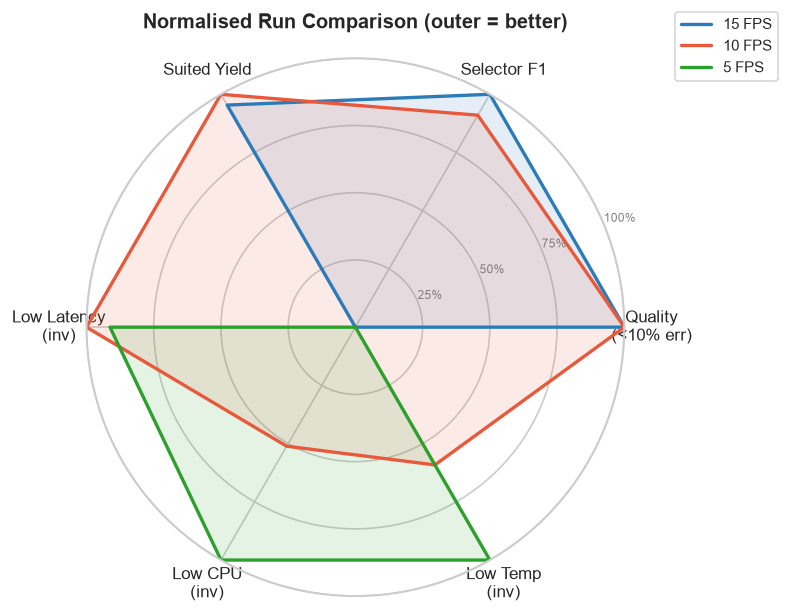

In [17]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# Normalise each metric to [0,1] where 1 = best
radar_metrics = {
    "Quality\n(<10% err)":  (lambda r: (r["df_report"][~r["df_report"].is_outlier]["rel_error_pct"] < 10).mean()*100, "higher"),
    "Selector F1":           (lambda r: r["df_report"][~r["df_report"].is_outlier]["f1"].mean()*100, "higher"),
    "Suited Yield":          (lambda r: r["df_animals"]["suitable_images"].sum()/r["df_animals"]["total_of_images"].sum()*100, "higher"),
    "Low Latency\n(inv)":   (lambda r: 1/max(r["df_animals"]["by_animal_latency_sec"].mean(), 0.001), "higher"),
    "Low CPU\n(inv)":       (lambda r: 100 - r["df_cpu"]["cpu_mean"].mean(), "higher"),
    "Low Temp\n(inv)":      (lambda r: 100 - r["df_temp"]["temperature"].mean(), "higher"),
}

labels = list(radar_metrics.keys())
K      = len(labels)
angles = np.linspace(0, 2*np.pi, K, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

raw_values = {run["label"]: [] for run in LOADED}
for metric, (fn, _) in radar_metrics.items():
    vals = [fn(run) for run in LOADED]
    mn, mx = min(vals), max(vals)
    for run, v in zip(LOADED, vals):
        norm = (v - mn) / (mx - mn + 1e-9)
        raw_values[run["label"]].append(norm)

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for (run_label, vals), color in zip(raw_values.items(), RUN_COLORS[:n]):
    v = vals + vals[:1]
    ax.plot(angles, v, color=color, lw=2, label=run_label)
    ax.fill(angles, v, color=color, alpha=0.12)

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["25%", "50%", "75%", "100%"], fontsize=7, color="grey")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=9)
ax.set_title("Normalised Run Comparison (outer = better)", pad=18, fontweight="bold")
plt.tight_layout()
plt.savefig("cmp_radar.png", dpi=120, bbox_inches="tight")
plt.show()


## 15. Key Insights & Recommendations

> **Fill in after running:** the cells below auto-print a structured summary. Use it as the basis for your conclusions.


In [18]:
print("=" * 65)
print("  CROSS-RUN COMPARISON SUMMARY")
print("=" * 65)

for run in LOADED:
    drc  = run["df_report"][~run["df_report"].is_outlier]
    da   = run["df_animals"]
    label = run["label"]

    t0  = da["first_image_capture_time"].min()
    t1  = da["weight_prediction_final"].max()
    dur = (t1 - t0).total_seconds()

    print(f"\n── {label} ──────────────────────────────────────────")
    print(f"  Duration             : {dur/60:.1f} min")
    print(f"  Animals              : {da['animal_id'].nunique()}")
    print(f"  Avg frames/animal    : {da['total_of_images'].mean():.1f}")
    print(f"  Avg suited/animal    : {da['suitable_images'].mean():.1f}")
    print(f"  Suited ratio         : {da['suitable_images'].sum()/da['total_of_images'].sum()*100:.1f}%")
    print(f"  MAE                  : {drc['abs_error'].mean():.3f} kg")
    print(f"  MAPE                 : {drc['rel_error_pct'].mean():.2f}%")
    print(f"  Median rel error     : {drc['rel_error_pct'].median():.2f}%")
    print(f"  Animals < 10% error  : {(drc['rel_error_pct'] < 10).mean()*100:.1f}%")
    print(f"  Avg F1               : {drc['f1'].mean():.4f}")
    print(f"  Avg lead time        : {da['by_animal_lead_time_sec'].mean():.3f} s")
    print(f"  Avg latency          : {da['by_animal_latency_sec'].mean():.3f} s")
    print(f"  Avg CPU              : {run['df_cpu']['cpu_mean'].mean():.2f}%")
    print(f"  Avg Temp             : {run['df_temp']['temperature'].mean():.2f} °C")
    print(f"  Peak Temp            : {run['df_temp']['temperature'].max():.1f} °C")
    print(f"  Model load time      : {run['load_model_ms']:.1f} ms")

print("\n" + "=" * 65)
print("  TRADEOFF ANALYSIS")
print("=" * 65)
print("\nSpearman ρ — suited frames vs relative error (per run):")
for run in LOADED:
    drc = run["df_report"][~run["df_report"].is_outlier]
    rho, pv = spearmanr(drc["suited_pred"], drc["rel_error_pct"])
    sig = "***" if pv < 0.001 else ("**" if pv < 0.01 else ("*" if pv < 0.05 else "ns"))
    print(f"  {run['label']:<12}: ρ = {rho:+.3f}  ({sig})")

print("\nKey tradeoff questions to answer with your results:")
print("  1. Does higher FPS → more suited frames, or does the selector saturate?")
print("  2. Does more suited frames → lower prediction error?")
print("  3. What is the marginal resource cost (CPU/temp) of increasing FPS?")
print("  4. Is there a FPS 'sweet spot' that maximises quality per watt?")


  CROSS-RUN COMPARISON SUMMARY

── 15 FPS ──────────────────────────────────────────
  Duration             : 24.9 min
  Animals              : 189
  Avg frames/animal    : 114.5
  Avg suited/animal    : 14.0
  Suited ratio         : 12.2%
  MAE                  : 1.800 kg
  MAPE                 : 6.22%
  Median rel error     : 5.12%
  Animals < 10% error  : 80.3%
  Avg F1               : 0.9452
  Avg lead time        : 8.365 s
  Avg latency          : 0.590 s
  Avg CPU              : 32.86%
  Avg Temp             : 65.31 °C
  Peak Temp            : 78.8 °C
  Model load time      : 43.2 ms

── 10 FPS ──────────────────────────────────────────
  Duration             : 24.6 min
  Animals              : 189
  Avg frames/animal    : 76.6
  Avg suited/animal    : 9.4
  Suited ratio         : 12.2%
  MAE                  : 1.868 kg
  MAPE                 : 6.55%
  Median rel error     : 5.11%
  Animals < 10% error  : 80.3%
  Avg F1               : 0.9444
  Avg lead time        : 7.808 s
  Av